# PrediRuta: estado del actor

En este notebook se explorará la construcción del modelo de `estado de la victima según PrediRuta`. Por medio de la estimación de la probabilidad de consecuencia para una persona involucrada en un accidente de tránsito, clasificándola como `HERIDO`, `ILESO` o `MUERTO`. 

Se plantea utilizar información espacial, temporal, meteorológica y características disponibles del actor y del vehículo, incorporando las 150 zonas definidas por el modelo de ocurrencia. El notebook compara un escenario completo (todas las variables) con uno operativo (variables que un usuario de PrediRuta puede conocer al iniciar el trayecto). Se excluye la categoría `SIN INFORMACIÓN` para disminuir posible ruido para entrenar los diferentes modelos. 

Por medio de la evaluación de diferentes algoritmos mediante una partición temporal, se pretende determinar si es posible anticipar el estado del actor usando información disponible o derivable en una consulta real (variables climáticas).

**Consideraciones metodológicas**

1. Cada celda se asigna a una de las 150 zonas construidas para el modelo de ocurrencia.
2. La categoría `SIN INFORMACIÓN` se excluye antes de dividir los datos.
3. Los escenarios `completo` y `operativo` utilizan las mismas observaciones.
4. Los hiperparámetros se calibran independientemente para cada escenario.
5. Los modelos se entrenan con datos hasta 2020 y se seleccionan usando el periodo 2021–2023.
6. Los modelos seleccionados se reajustan con información hasta 2023 y se evalúan en 2024–2026.
7. La variable `ANIO` se utiliza para realizar la partición temporal, pero no como predictor.
8. Como análisis de sensibilidad se añade una partición aleatoria con todos los años, agrupada por `ACCIDENTE_ID`; esta comparación no sustituye la evaluación temporal.

## 0. Configuración

In [1]:
# Librerías y parámetros generales
from pathlib import Path
from time import perf_counter
import json
import os
import random
import sys
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pyproj import Transformer
from scipy.spatial import cKDTree
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score, log_loss,
    precision_recall_curve, roc_auc_score, roc_curve
)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
warnings.filterwarnings('ignore', category=FutureWarning)


In [2]:


SEMILLA = 42
NUMERO_ZONAS = 150
TAMANO_CELDA_METROS = 500
VARIABLES_CLIMA_ORIGINALES = [
    'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA',
    'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M'
]
VARIABLES_CLIMA_RETIRADAS_CORRELACION = [
    'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA', 'LLUVIA'
]
VARIABLES_CLIMA_CRUDAS = [
    variable for variable in VARIABLES_CLIMA_ORIGINALES
    if variable not in VARIABLES_CLIMA_RETIRADAS_CORRELACION
]
random.seed(SEMILLA)
np.random.seed(SEMILLA)

print(f'Python: {sys.version.split()[0]}')

Python: 3.9.6


In [3]:
# Resolver rutas sin depender de si el notebook se abre desde la raíz o desde modelo/
def encontrar_raiz_proyecto():
    candidatas = [Path.cwd(), *Path.cwd().parents]
    for candidata in candidatas:
        archivo_esperado = candidata / 'data' / 'data_procesada' / 'modelado' / 'DATASET_EVENTOS.csv'
        if archivo_esperado.exists():
            return candidata
    raise FileNotFoundError('No se encontró la raíz de PrediRuta ni DATASET_EVENTOS.csv')

RAIZ_PROYECTO = encontrar_raiz_proyecto()
CARPETA_DATOS = RAIZ_PROYECTO / 'data' / 'data_procesada' / 'modelado'

RUTA_EVENTOS = CARPETA_DATOS / 'DATASET_EVENTOS.csv'
RUTA_OCURRENCIA = CARPETA_DATOS / 'DATASET_OCURRENCIA.csv'
RUTA_COMPLETA = CARPETA_DATOS / 'TABLA_COMPLETA_ACCIDENTES.csv'
RUTA_ACTORES = CARPETA_DATOS / 'ACTOR_VIAL.csv'
RUTA_VEHICULOS = CARPETA_DATOS / 'VEHICULO.csv'
RUTA_DICCIONARIO = CARPETA_DATOS / 'DICCIONARIO_CATEGORIAS.csv'

print(f'Raíz del proyecto: {RAIZ_PROYECTO}')


Raíz del proyecto: /Users/leonardoguzman/Documents/MIAD/Proyecto aplicado en analítica de datos/Prediruta


## 1. Carga e integración de los datos

`DATASET_EVENTOS` aporta el contexto espacial, temporal, meteorológico y la clase del accidente. Antes de integrarlo con los actores se asigna cada celda a una de las 150 zonas construidas para `DATASET_OCURRENCIA`. Así, todos los modelos usan la misma partición de Bogotá. Luego se incorporan las características de la vía y el vehículo asociado. La unión accidente–actor es uno a muchos: cada fila final representa una persona involucrada.

In [4]:
# Variables que pueden conocerse al caracterizar al actor involucrado
COLUMNAS_VIA_CATEGORICAS = [
    'GEOMETRIA_PLANTA', 'GEOMETRIA_TERRENO', 'GEOMETRIA_SECCION',
    'SENTIDO_VIA', 'SUPERFICIE_RODADURA', 'ESTADO_VIA',
    'CONDICION_VIA', 'ILUMINACION_ARTIFICIAL', 'SEMAFORO'
]
COLUMNAS_VIA_NUMERICAS = ['N_CALZADAS', 'N_CARRILES']
COLUMNAS_VIA = [*COLUMNAS_VIA_CATEGORICAS, *COLUMNAS_VIA_NUMERICAS]
COLUMNAS_ACTOR = ['ACTOR_ID', 'VEHICULO_ID', 'CONDICION', 'ESTADO', 'GENERO', 'EDAD']
COLUMNAS_VEHICULO = ['CLASE', 'SERVICIO']

eventos = pd.read_csv(
    RUTA_EVENTOS, encoding='utf-8-sig', parse_dates=['FECHA_HORA'], low_memory=False
)
tabla_completa = pd.read_csv(
    RUTA_COMPLETA, encoding='utf-8-sig',
    usecols=['ACCIDENTE_ID', *COLUMNAS_VIA], low_memory=False
)
actores = pd.read_csv(
    RUTA_ACTORES, encoding='utf-8-sig', usecols=['ACCIDENTE_ID', *COLUMNAS_ACTOR], low_memory=False
)
vehiculos = pd.read_csv(
    RUTA_VEHICULOS, encoding='utf-8-sig',
    usecols=['ACCIDENTE_ID', 'VEHICULO_ID', *COLUMNAS_VEHICULO], low_memory=False
).rename(columns={'CLASE': 'CLASE_VEHICULO', 'SERVICIO': 'SERVICIO_VEHICULO'})
diccionario = pd.read_csv(RUTA_DICCIONARIO, encoding='utf-8-sig')

# Recuperar exactamente las zonas creadas para el modelo de ocurrencia
centroides_zona = (
    pd.read_csv(
        RUTA_OCURRENCIA, encoding='utf-8-sig',
        usecols=['ZONA_CIUDAD', 'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']
    )
    .drop_duplicates()
    .sort_values('ZONA_CIUDAD')
    .reset_index(drop=True)
)
assert len(centroides_zona) == NUMERO_ZONAS
assert centroides_zona['ZONA_CIUDAD'].nunique() == NUMERO_ZONAS

# KMeans se ajustó con los centros de las celdas de 500 m. Se reconstruye
# el centro de cada celda y se asigna al centroide más cercano, equivalente
# a predict() de KMeans cuando sus centroides ya están fijados.
bogota_a_wgs84 = Transformer.from_crs('EPSG:3116', 'EPSG:4326', always_xy=True)
celdas_evento = eventos[['CELDA_ID', 'CELDA_X', 'CELDA_Y']].drop_duplicates().copy()
x_centro = (celdas_evento['CELDA_X'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
y_centro = (celdas_evento['CELDA_Y'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
lon_centro, lat_centro = bogota_a_wgs84.transform(x_centro, y_centro)
celdas_evento['LATITUD_CELDA'] = lat_centro
celdas_evento['LONGITUD_CELDA'] = lon_centro

arbol_zonas = cKDTree(
    centroides_zona[['LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']].to_numpy()
)
_, posiciones_zona = arbol_zonas.query(
    celdas_evento[['LATITUD_CELDA', 'LONGITUD_CELDA']].to_numpy(), k=1
)
celdas_evento['ZONA_CIUDAD'] = (
    centroides_zona.iloc[posiciones_zona]['ZONA_CIUDAD'].to_numpy().astype('int16')
)
eventos = eventos.merge(
    celdas_evento[['CELDA_ID', 'ZONA_CIUDAD']],
    on='CELDA_ID', how='left', validate='m:1'
)
assert eventos['ZONA_CIUDAD'].notna().all()
assert eventos['ZONA_CIUDAD'].nunique() == NUMERO_ZONAS

accidentes = eventos.merge(tabla_completa, on='ACCIDENTE_ID', how='left', validate='1:1')
datos = actores.merge(accidentes, on='ACCIDENTE_ID', how='inner', validate='m:1')
datos = datos.merge(vehiculos, on=['ACCIDENTE_ID', 'VEHICULO_ID'], how='left', validate='m:1')

inventario = pd.DataFrame({
    'TABLA': ['ACCIDENTES', 'ACTORES', 'ACTORES_MODELABLES'],
    'FILAS': [len(accidentes), len(actores), len(datos)],
    'UNIDADES_UNICAS': [accidentes['ACCIDENTE_ID'].nunique(), actores['ACTOR_ID'].nunique(), datos['ACTOR_ID'].nunique()],
})
display(inventario)
display(datos.head())
datos.info()

,TABLA,FILAS,UNIDADES_UNICAS
0,ACCIDENTES,895346,895346
1,ACTORES,1927486,1927486
2,ACTORES_MODELABLES,1927486,1927486


,ACCIDENTE_ID,ACTOR_ID,VEHICULO_ID,CONDICION,ESTADO,GENERO,EDAD,CELDA_ID,FECHA_HORA,LATITUD,...,SENTIDO_VIA,N_CALZADAS,N_CARRILES,SUPERFICIE_RODADURA,ESTADO_VIA,CONDICION_VIA,ILUMINACION_ARTIFICIAL,SEMAFORO,CLASE_VEHICULO,SERVICIO_VEHICULO
0,104,19279,10402.0,3,2,1,28.0,2001_2004,2008-01-14 17:40:00,4.617262,...,0,NaN,NaN,0,0,0,0,0,1.0,3.0
1,104,19280,10403.0,3,2,2,41.0,2001_2004,2008-01-14 17:40:00,4.617262,...,0,NaN,NaN,0,0,0,0,0,3.0,4.0
2,105,19281,10502.0,3,2,2,56.0,2005_2014,2008-01-08 19:20:00,4.662820,...,0,NaN,NaN,0,0,0,0,0,4.0,4.0
3,105,19282,10503.0,3,2,2,53.0,2005_2014,2008-01-08 19:20:00,4.662820,...,0,NaN,NaN,0,0,0,0,0,1.0,3.0
4,106,19283,10602.0,3,2,2,23.0,2001_2003,2008-01-11 08:30:00,4.612378,...,0,NaN,NaN,0,0,0,0,0,11.0,4.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927486 entries, 0 to 1927485
Data columns (total 43 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   ACCIDENTE_ID            int64         
 1   ACTOR_ID                int64         
 2   VEHICULO_ID             float64       
 3   CONDICION               int64         
 4   ESTADO                  int64         
 5   GENERO                  int64         
 6   EDAD                    float64       
 7   CELDA_ID                object        
 8   FECHA_HORA              datetime64[ns]
 9   LATITUD                 float64       
 10  LONGITUD                float64       
 11  CELDA_X                 int64         
 12  CELDA_Y                 int64         
 13  ANIO                    int64         
 14  MES                     int64         
 15  DIA_SEMANA              int64         
 16  HORA                    int64         
 17  FIN_SEMANA              int64         
 18  TE

In [5]:
# Estadísticas descriptivas de las variables numéricas
columnas_no_descriptivas = ['ACCIDENTE_ID', 'ACTOR_ID', 'VEHICULO_ID', 'CLIMA_ID']
descriptivas = (
    datos.select_dtypes(include='number')
    .drop(columns=columnas_no_descriptivas, errors='ignore')
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
)
display(descriptivas)

,count,mean,std,min,5%,25%,50%,75%,95%,max
CONDICION,1927486.0,3.668327,1.154230,0.000000,3.000000,3.000000,3.000000,4.000000,6.000000,6.000000
ESTADO,1927486.0,1.754555,0.456513,0.000000,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000
GENERO,1927486.0,1.791156,0.458010,0.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000
EDAD,1884130.0,37.321834,13.942198,0.000000,19.000000,27.000000,35.000000,46.000000,62.000000,108.000000
LATITUD,1927486.0,4.649918,0.055946,4.469744,4.562112,4.610076,4.646224,4.690118,4.744394,4.823186
LONGITUD,1927486.0,-74.101869,0.039792,-74.218642,-74.170682,-74.131225,-74.100209,-74.070801,-74.041561,-74.013247
CELDA_X,1927486.0,1994.091012,8.828194,1968.000000,1979.000000,1988.000000,1994.000000,2001.000000,2007.000000,2014.000000
CELDA_Y,1927486.0,2011.374009,12.373658,1972.000000,1992.000000,2003.000000,2011.000000,2020.000000,2032.000000,2050.000000
ANIO,1927486.0,2014.721656,4.787509,2007.000000,2007.000000,2011.000000,2015.000000,2018.000000,2023.000000,2026.000000
MES,1927486.0,6.588653,3.427532,1.000000,1.000000,4.000000,7.000000,10.000000,12.000000,12.000000


In [6]:
# Catálogo para interpretar la variable objetivo
catalogo_estados = (
    diccionario.query("TABLA == 'ACTOR_VIAL' and COLUMNA == 'ESTADO'")
    .set_index('CODIGO')['DESCRIPCION']
    .to_dict()
)

resumen_objetivo = datos['ESTADO'].value_counts(dropna=False).sort_index().rename('CASOS').to_frame()
resumen_objetivo['PORCENTAJE'] = 100 * resumen_objetivo['CASOS'] / len(datos)
resumen_objetivo['DESCRIPCION'] = [catalogo_estados.get(codigo, 'NO CATALOGADA') for codigo in resumen_objetivo.index]
display(resumen_objetivo)

,CASOS,PORCENTAJE,DESCRIPCION
ESTADO,,,
0,6806,0.353102,SIN INFORMACION
1,475035,24.645315,HERIDO
2,1430090,74.194573,ILESO
3,15555,0.807010,MUERTO


## 2. Análisis descriptivo del estado del actor

Antes de modelar se revisan las frecuencias y estabilidad temporal de las cuatro categorías originales. La descriptiva permite cuantificar los registros que se retirarán y comprobar que `HERIDO`, `ILESO` y `MUERTO` permanecen en los tres periodos.

,SIN INFORMACION,HERIDO,ILESO,MUERTO
ANIO,,,,
2007,54,27185,96056,850
2008,76,19666,96871,629
2009,12,17402,75414,693
2010,4,24521,87943,808
2011,2,24896,92773,883
2012,0,26701,95629,884
2013,0,25596,98054,833
2014,367,24418,95041,989
2015,1076,26284,90955,1057


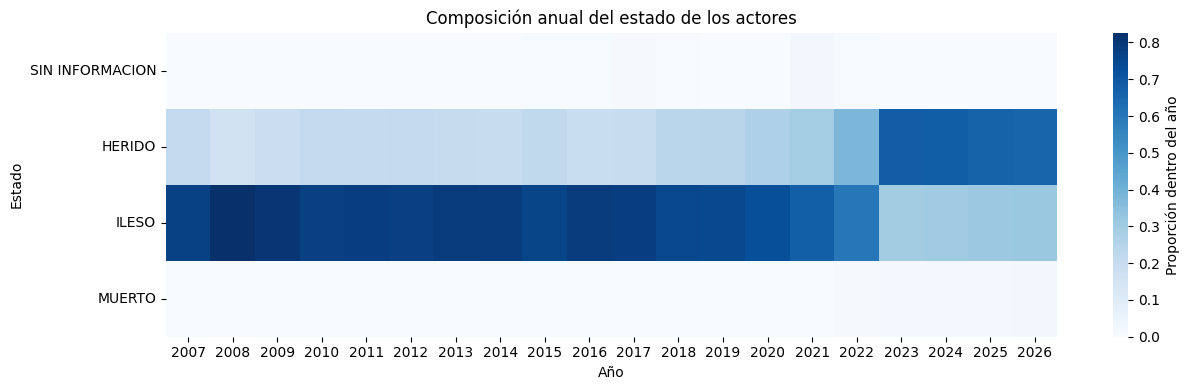

In [7]:
# Distribución temporal de los estados
conteo_anual = pd.crosstab(datos['ANIO'], datos['ESTADO'])
conteo_anual.columns = [catalogo_estados.get(codigo, str(codigo)) for codigo in conteo_anual.columns]
display(conteo_anual)

fig, ax = plt.subplots(figsize=(13, 4))
proporcion_anual = conteo_anual.div(conteo_anual.sum(axis=1), axis=0)
sns.heatmap(proporcion_anual.T, cmap='Blues', ax=ax, cbar_kws={'label': 'Proporción dentro del año'})
ax.set_title('Composición anual del estado de los actores')
ax.set_xlabel('Año')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

In [8]:
# Presencia de cada estado a lo largo del tiempo
resumen_estados = (
    datos.groupby('ESTADO')
    .agg(CASOS=('ACTOR_ID', 'size'), PRIMER_ANIO=('ANIO', 'min'),
         ULTIMO_ANIO=('ANIO', 'max'), ANIOS_CON_REGISTROS=('ANIO', 'nunique'))
    .reset_index()
)
resumen_estados['DESCRIPCION'] = resumen_estados['ESTADO'].map(catalogo_estados)
resumen_estados['PORCENTAJE_TOTAL'] = 100 * resumen_estados['CASOS'] / len(datos)
display(resumen_estados)

,ESTADO,CASOS,PRIMER_ANIO,ULTIMO_ANIO,ANIOS_CON_REGISTROS,DESCRIPCION,PORCENTAJE_TOTAL
0,0,6806,2007,2026,18,SIN INFORMACION,0.353102
1,1,475035,2007,2026,20,HERIDO,24.645315
2,2,1430090,2007,2026,20,ILESO,74.194573
3,3,15555,2007,2026,20,MUERTO,0.807010


### Decisión sobre las clases de salida

Se retira `SIN INFORMACION` (`ESTADO = 0`) porque no describe una consecuencia del accidente y su desempeño anterior fue muy bajo. Mantenerla obligaba a la ponderación de clases a perseguir un patrón de ausencia de registro, generando numerosos falsos positivos. El nuevo objetivo contiene exclusivamente `HERIDO`, `ILESO` y `MUERTO`.

In [9]:
# Retirar SIN INFORMACION antes de cualquier partición o ajuste
CODIGO_SIN_INFORMACION = 0
estados_modelados = [1, 2, 3]
datos_modelo = datos.loc[datos['ESTADO'].isin(estados_modelados)].copy()

print(f'Registros iniciales: {len(datos):,}')
print(f'Registros SIN INFORMACION retirados: {(datos["ESTADO"] == CODIGO_SIN_INFORMACION).sum():,}')
print(f'Registros con estado clínico: {len(datos_modelo):,}')
print(f'Actores únicos: {datos_modelo["ACTOR_ID"].nunique():,}')

Registros iniciales: 1,927,486
Registros SIN INFORMACION retirados: 6,806
Registros con estado clínico: 1,920,680
Actores únicos: 1,920,680


,CASOS,PORCENTAJE,DESCRIPCION
ESTADO,,,
1,475035,24.732647,HERIDO
2,1430090,74.457484,ILESO
3,15555,0.809869,MUERTO


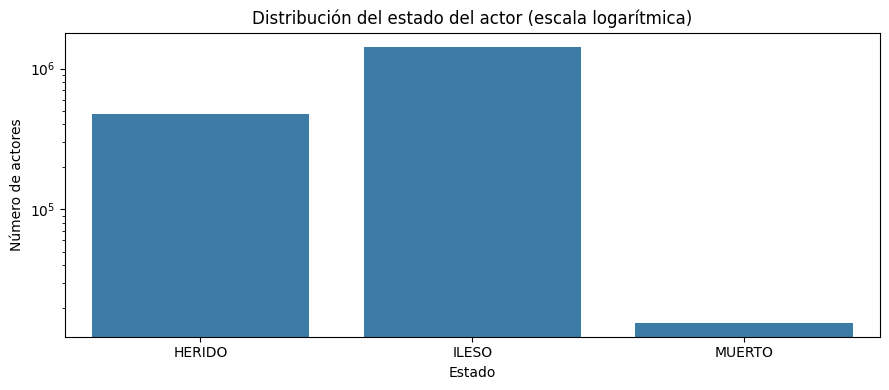

,PORCENTAJE_FALTANTES
N_CARRILES,45.127299
N_CALZADAS,45.127299
SERVICIO_VEHICULO,6.511288
CLASE_VEHICULO,6.511288
EDAD,1.915103
CONDICION,0.000000
GEOMETRIA_PLANTA,0.000000
GEOMETRIA_TERRENO,0.000000
GEOMETRIA_SECCION,0.000000
SENTIDO_VIA,0.000000


In [10]:
# Desbalance de los tres estados y faltantes de las variables candidatas
resumen_estados_modelo = datos_modelo['ESTADO'].value_counts().sort_index().rename('CASOS').to_frame()
resumen_estados_modelo['PORCENTAJE'] = 100 * resumen_estados_modelo['CASOS'] / len(datos_modelo)
resumen_estados_modelo['DESCRIPCION'] = [catalogo_estados[codigo] for codigo in resumen_estados_modelo.index]
display(resumen_estados_modelo)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=resumen_estados_modelo.reset_index(), x='DESCRIPCION', y='CASOS', ax=ax, color='#2C7FB8')
ax.set_yscale('log')
ax.set_title('Distribución del estado del actor (escala logarítmica)')
ax.set_xlabel('Estado')
ax.set_ylabel('Número de actores')
plt.tight_layout()
plt.show()

columnas_candidatas = list(dict.fromkeys([
    'LATITUD', 'LONGITUD', 'CELDA_X', 'CELDA_Y', 'ZONA_CIUDAD',
    'MES', 'DIA_SEMANA', 'HORA', 'GENERO', 'EDAD',
    'CLASE_VEHICULO', 'SERVICIO_VEHICULO', *VARIABLES_CLIMA_CRUDAS,
    'CLASE_ACCIDENTE', 'CONDICION', *COLUMNAS_VIA
]))
faltantes = datos_modelo[columnas_candidatas].isna().mean().mul(100).rename('PORCENTAJE_FALTANTES').sort_values(ascending=False).to_frame()
display(faltantes)

### 2.1 Distribuciones numéricas y relaciones continuas

Se amplía la revisión descriptiva del notebook de ocurrencia, pero se evita calcular correlaciones sobre códigos categóricos: sus números son etiquetas y no magnitudes. Los histogramas y la matriz siguiente se limitan a variables continuas y utilizan una muestra reproducible para mantener razonable el costo gráfico.

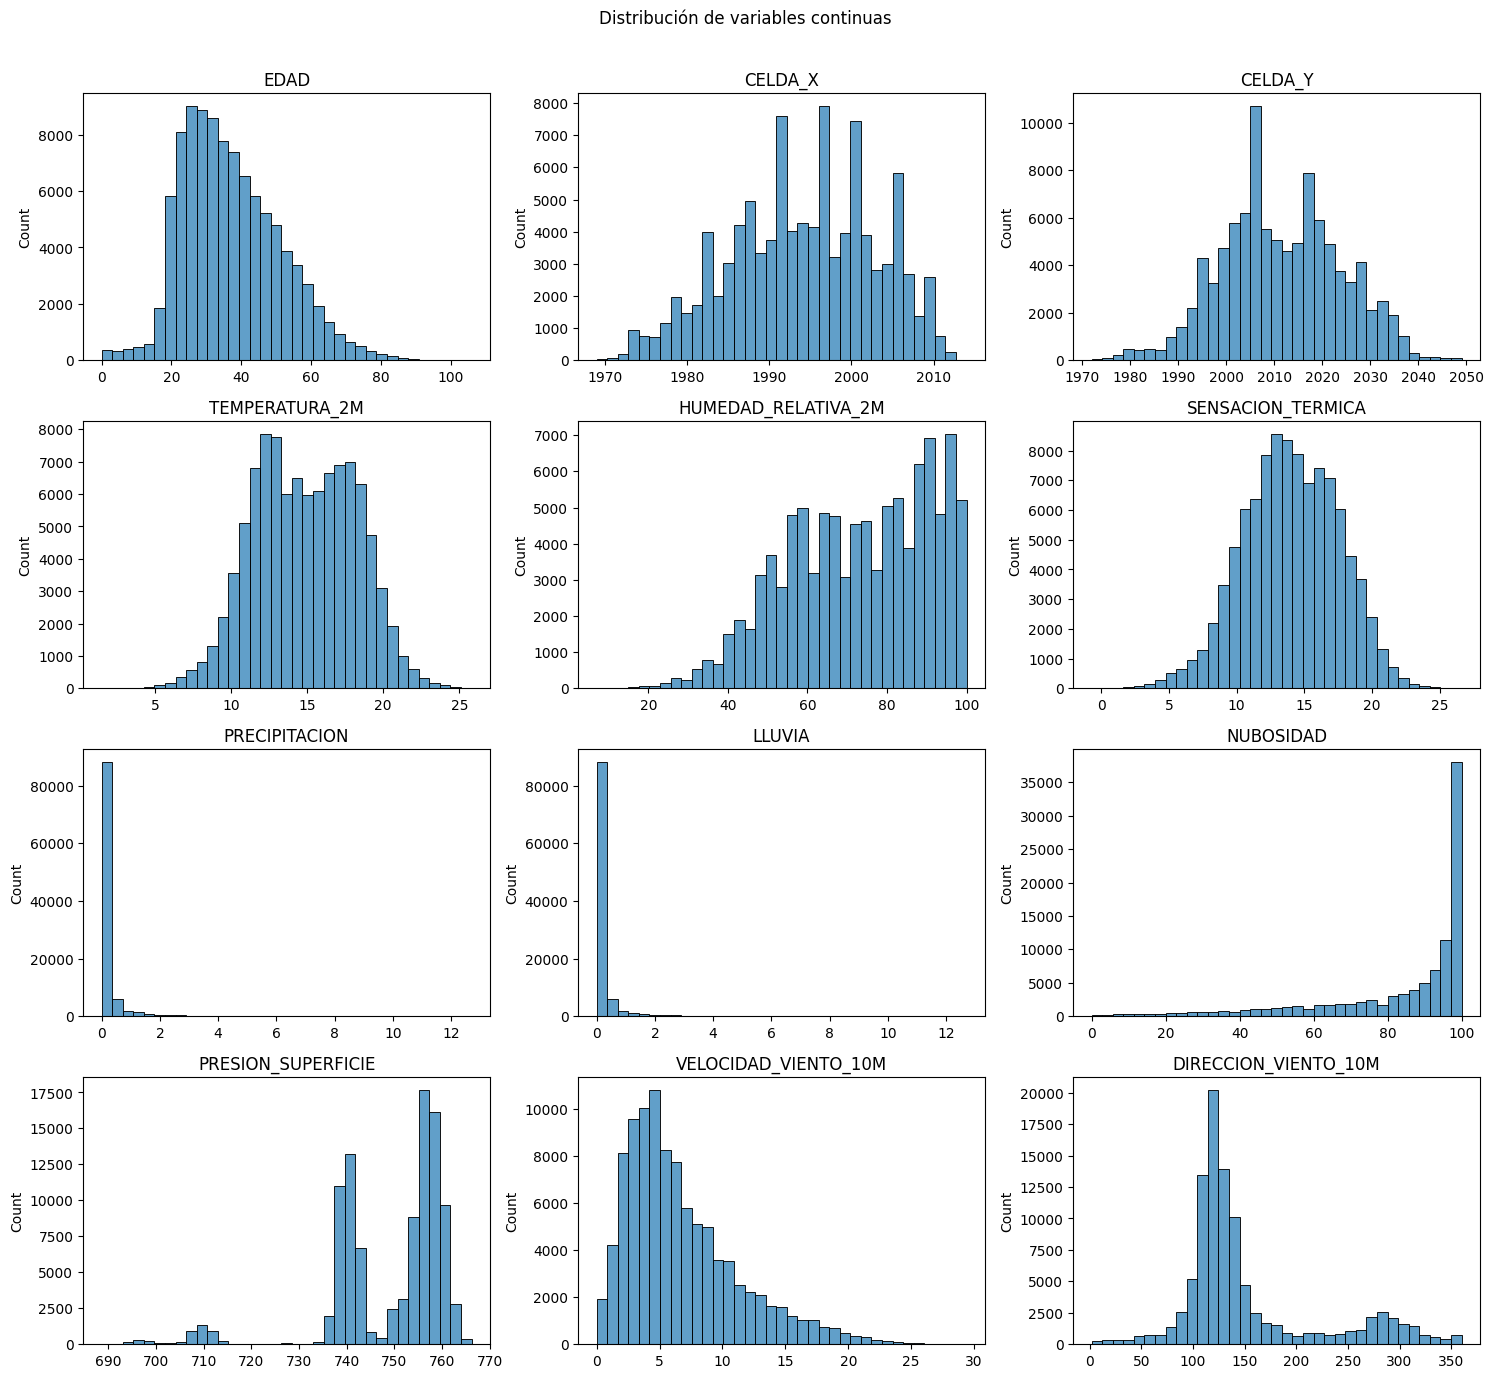

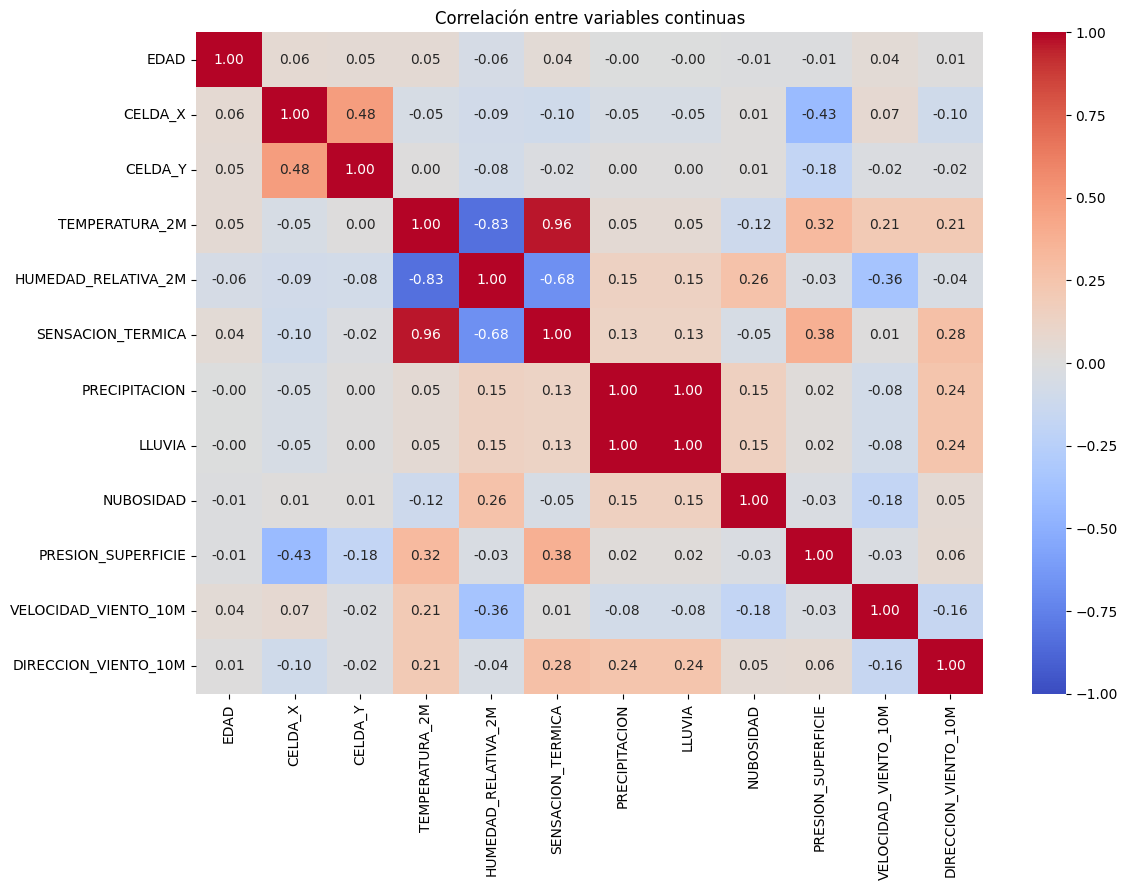

In [11]:
variables_continuas = [
    'EDAD', 'CELDA_X', 'CELDA_Y', *VARIABLES_CLIMA_ORIGINALES
]
muestra_descriptiva = datos_modelo[variables_continuas].sample(
    n=min(100_000, len(datos_modelo)), random_state=SEMILLA
)

columnas_grafico = 3
filas_grafico = int(np.ceil(len(variables_continuas) / columnas_grafico))
fig, axes = plt.subplots(
    filas_grafico, columnas_grafico,
    figsize=(15, 3.4 * filas_grafico)
)
for ax, columna in zip(axes.flat, variables_continuas):
    sns.histplot(muestra_descriptiva[columna], bins=35, ax=ax, color='#2C7FB8')
    ax.set_title(columna)
    ax.set_xlabel('')
for ax in axes.flat[len(variables_continuas):]:
    ax.set_visible(False)
fig.suptitle('Distribución de variables continuas', y=1.01)
plt.tight_layout()
plt.show()

correlaciones = muestra_descriptiva.corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    correlaciones, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', ax=ax
)
ax.set_title('Correlación entre variables continuas')
plt.tight_layout()
plt.show()

### 2.2 Selección de variables meteorológicas por correlación

Para reducir redundancia se adopta un umbral de correlación absoluta de 0,80. Este criterio no implica que una variable correlacionada carezca de significado físico; únicamente evita entregar al modelo dos mediciones que representan casi la misma señal. Cuando una pareja supera el umbral se conserva la variable más directa e interpretable para una consulta operativa.

In [12]:
UMBRAL_CORRELACION = 0.80
decisiones_correlacion = pd.DataFrame([
    {'VARIABLE_CONSERVADA': 'TEMPERATURA_2M', 'VARIABLE_RETIRADA': 'SENSACION_TERMICA'},
    {'VARIABLE_CONSERVADA': 'PRECIPITACION', 'VARIABLE_RETIRADA': 'LLUVIA'},
    {'VARIABLE_CONSERVADA': 'TEMPERATURA_2M', 'VARIABLE_RETIRADA': 'HUMEDAD_RELATIVA_2M'},
])
decisiones_correlacion['CORRELACION'] = decisiones_correlacion.apply(
    lambda fila: correlaciones.loc[fila['VARIABLE_CONSERVADA'], fila['VARIABLE_RETIRADA']],
    axis=1,
)
decisiones_correlacion['CORRELACION_ABSOLUTA'] = decisiones_correlacion['CORRELACION'].abs()
decisiones_correlacion['SUPERA_UMBRAL'] = (
    decisiones_correlacion['CORRELACION_ABSOLUTA'] >= UMBRAL_CORRELACION
)
assert decisiones_correlacion['SUPERA_UMBRAL'].all()
display(decisiones_correlacion.round(3))

,VARIABLE_CONSERVADA,VARIABLE_RETIRADA,CORRELACION,CORRELACION_ABSOLUTA,SUPERA_UMBRAL
0,TEMPERATURA_2M,SENSACION_TERMICA,0.961,0.961,True
1,PRECIPITACION,LLUVIA,0.996,0.996,True
2,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,-0.829,0.829,True


Se retira `SENSACION_TERMICA` y se conserva `TEMPERATURA_2M`, porque la primera es una medida derivada y ambas presentan una relación casi lineal. Se retira `LLUVIA` y se conserva `PRECIPITACION`, ya que en estos datos son prácticamente equivalentes. También se retira `HUMEDAD_RELATIVA_2M`: aunque representa un fenómeno físico distinto, su correlación negativa con la temperatura supera el mismo umbral y su permanencia rompería el criterio aplicado a las otras parejas. El conjunto climático conserva temperatura, precipitación, nubosidad, presión y velocidad y dirección del viento.

### 2.3 Composición del estado por mes, día y hora

Como todos los registros corresponden a accidentes ocurridos, aquí no se vuelve a contar la ocurrencia. Se compara la proporción de `HERIDO`, `ILESO` y `MUERTO` dentro de cada mes, día de la semana y hora.

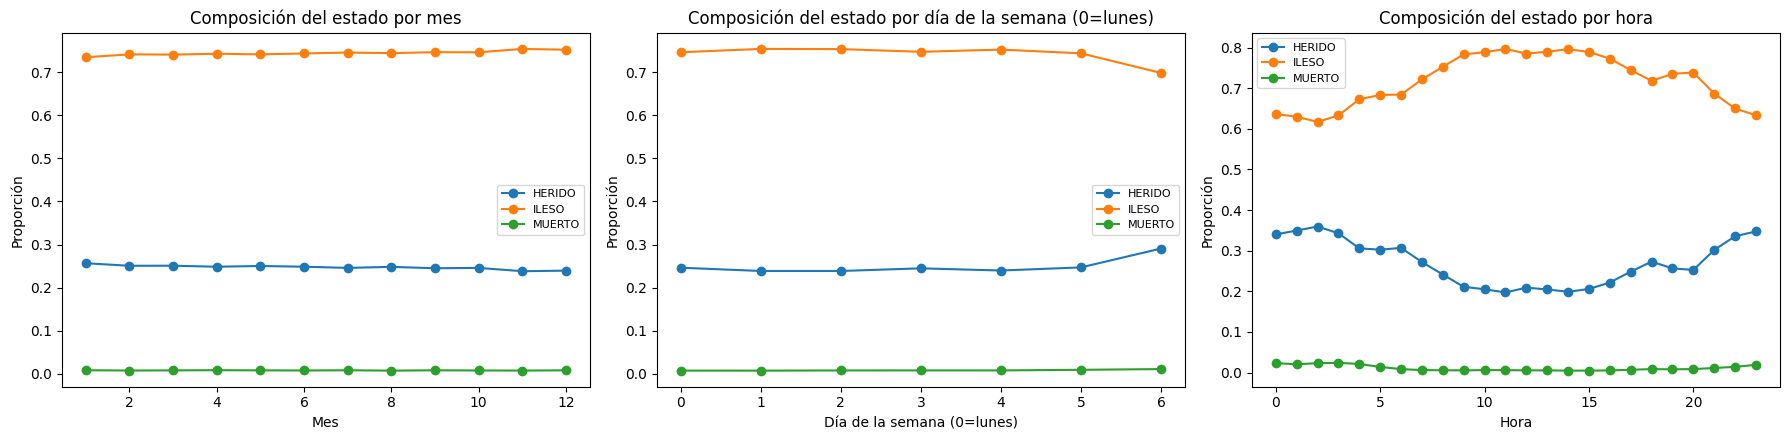

TEMPERATURA_2M        PRECIPITACION         NUBOSIDAD         \
                      mean median          mean median       mean median   
ESTADO_DESC                                                                
HERIDO           14.361309   14.0      0.154574    0.0  83.907407   95.0   
ILESO            14.992765   15.0      0.178012    0.0  83.785532   94.0   
MUERTO           13.916567   13.4      0.140964    0.0  84.526647   95.0   

            VELOCIDAD_VIENTO_10M         
                            mean median  
ESTADO_DESC                              
HERIDO                  6.729677    5.5  
ILESO                   6.747445    5.6  
MUERTO                  6.137506    5.1

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, columna, titulo in zip(
    axes, ['MES', 'DIA_SEMANA', 'HORA'],
    ['Mes', 'Día de la semana (0=lunes)', 'Hora']
):
    composicion = pd.crosstab(
        datos_modelo[columna], datos_modelo['ESTADO'], normalize='index'
    ).rename(columns=catalogo_estados)
    composicion.plot(ax=ax, marker='o', linewidth=1.5)
    ax.set_title(f'Composición del estado por {titulo.lower()}')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Proporción')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

resumen_clima_estado = (
    datos_modelo.assign(ESTADO_DESC=datos_modelo['ESTADO'].map(catalogo_estados))
    .groupby('ESTADO_DESC')[['TEMPERATURA_2M', 'PRECIPITACION', 'NUBOSIDAD', 'VELOCIDAD_VIENTO_10M']]
    .agg(['mean', 'median'])
)
display(resumen_clima_estado)

### 2.4 Descriptiva de las 150 zonas

Las zonas no se reajustan con las filas de actores, porque un accidente con más personas tendría mayor peso y produciría una partición distinta. Se reutilizan los centroides del modelo de ocurrencia y `ZONA_CIUDAD` se analiza como una categoría espacial, no como una escala numérica.

,count,mean,std,min,25%,50%,75%,max
ACTORES,150.0,12804.533333,4878.427154,622.0,9605.50,12331.0,15348.00,24561.0
ACCIDENTES,150.0,5960.126667,2278.705506,283.0,4475.25,5729.0,7182.25,11640.0


,ZONA_CIUDAD,ACTORES,ACCIDENTES,LATITUD_CENTROIDE,LONGITUD_CENTROIDE
51,51,24561,11640,4.720632,-74.051823
29,29,24106,11327,4.644874,-74.062205
76,76,24010,11511,4.603915,-74.074688
70,70,23340,10823,4.629379,-74.080767
12,12,23320,10825,4.630131,-74.119967
116,116,23307,10602,4.629776,-74.136337
102,102,21913,10142,4.598093,-74.091137
41,41,21893,10209,4.697094,-74.087579
5,5,21856,10097,4.640591,-74.157047
40,40,21781,10282,4.612003,-74.070541


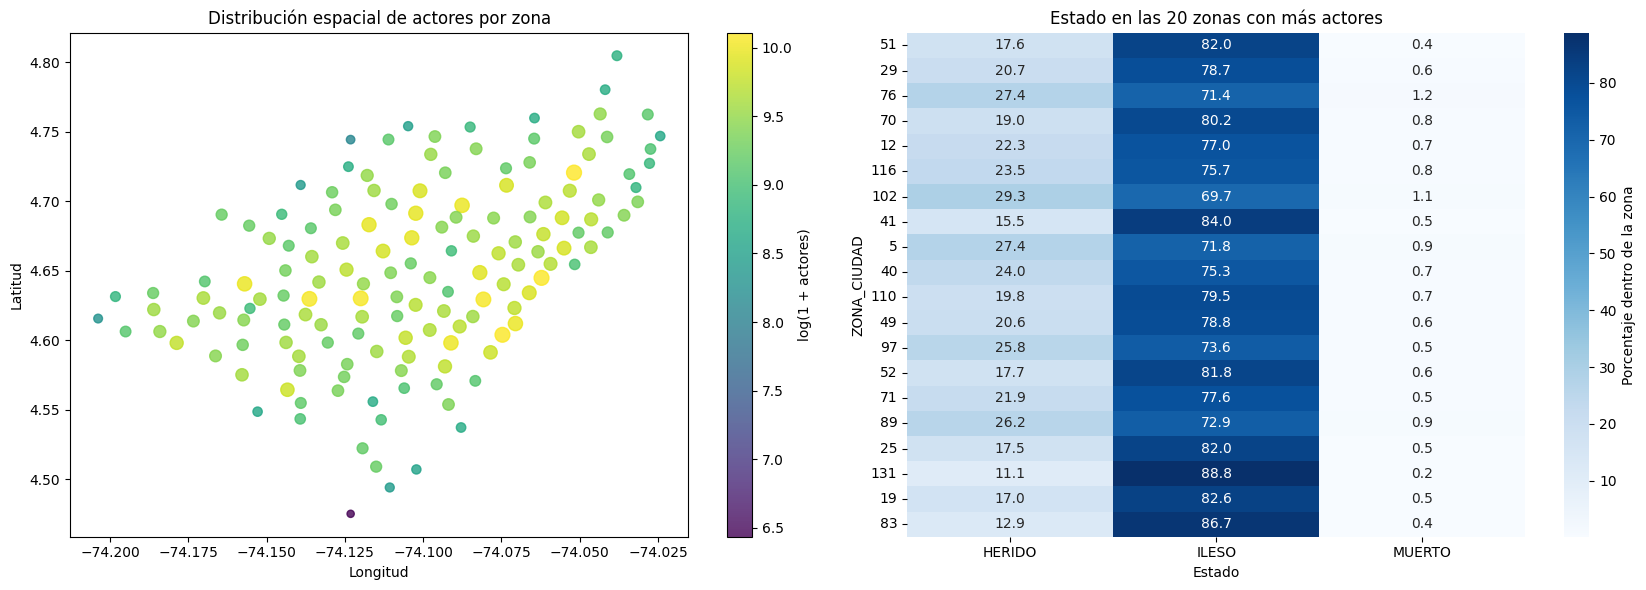

In [14]:
resumen_zonas = (
    datos_modelo.groupby('ZONA_CIUDAD')
    .agg(ACTORES=('ACTOR_ID', 'size'), ACCIDENTES=('ACCIDENTE_ID', 'nunique'))
    .reset_index()
    .merge(centroides_zona, on='ZONA_CIUDAD', how='left', validate='1:1')
)
composicion_zona = pd.crosstab(
    datos_modelo['ZONA_CIUDAD'], datos_modelo['ESTADO'], normalize='index'
).rename(columns=catalogo_estados)

assert len(resumen_zonas) == NUMERO_ZONAS
display(resumen_zonas[['ACTORES', 'ACCIDENTES']].describe().T)
display(resumen_zonas.nlargest(15, 'ACTORES'))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
dispersion = axes[0].scatter(
    resumen_zonas['LONGITUD_CENTROIDE'], resumen_zonas['LATITUD_CENTROIDE'],
    c=np.log1p(resumen_zonas['ACTORES']),
    s=25 + 90 * resumen_zonas['ACTORES'] / resumen_zonas['ACTORES'].max(),
    cmap='viridis', alpha=0.8
)
axes[0].set_title('Distribución espacial de actores por zona')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
fig.colorbar(dispersion, ax=axes[0], label='log(1 + actores)')

zonas_mayor_volumen = resumen_zonas.nlargest(20, 'ACTORES')['ZONA_CIUDAD']
sns.heatmap(
    100 * composicion_zona.loc[zonas_mayor_volumen],
    cmap='Blues', annot=True, fmt='.1f', ax=axes[1],
    cbar_kws={'label': 'Porcentaje dentro de la zona'}
)
axes[1].set_title('Estado en las 20 zonas con más actores')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('ZONA_CIUDAD')
plt.tight_layout()
plt.show()

## 3. Definición de los conjuntos de variables

El conjunto **completo** reproduce el notebook anterior y funciona como techo experimental. Contiene información que puede conocerse al documentar el accidente, pero que no necesariamente existe al consultar una ruta.

El conjunto **operativo** se limita a datos ingresables o derivables: ubicación, incluida la `ZONA_CIUDAD` asociada a la celda de 500 m; fecha y hora; edad y género del usuario; clase y servicio de su vehículo; y, cuando corresponda, clima pronosticado. Se retiran `CLASE_ACCIDENTE`, `CONDICION`, `N_CALZADAS`, `N_CARRILES` y todas las categorías detalladas de la vía.

En los escenarios con clima se excluyen además `SENSACION_TERMICA`, `LLUVIA` y `HUMEDAD_RELATIVA_2M` por superar el umbral de correlación absoluta de 0,80 definido en la descriptiva.

In [15]:
# Ingeniería temporal y circular
def agregar_variables_ciclicas(df):
    salida = df.copy()
    ciclos = {'MES': 12, 'DIA_SEMANA': 7, 'HORA': 24, 'DIRECCION_VIENTO_10M': 360}
    for columna, periodo in ciclos.items():
        angulo = 2 * np.pi * salida[columna].astype(float) / periodo
        salida[f'{columna}_SIN'] = np.sin(angulo)
        salida[f'{columna}_COS'] = np.cos(angulo)
    return salida

datos_modelo = agregar_variables_ciclicas(datos_modelo)

NUMERICAS_COMUNES = [
    'CELDA_X', 'CELDA_Y', 'EDAD',
    'MES_SIN', 'MES_COS', 'DIA_SEMANA_SIN', 'DIA_SEMANA_COS',
    'HORA_SIN', 'HORA_COS'
]
CATEGORICAS_COMUNES = [
    'MES', 'DIA_SEMANA', 'HORA', 'ZONA_CIUDAD', 'GENERO',
    'CLASE_VEHICULO', 'SERVICIO_VEHICULO'
]
NUMERICAS_COMPLETAS = [*NUMERICAS_COMUNES, *COLUMNAS_VIA_NUMERICAS]
CATEGORICAS_COMPLETAS = [
    *CATEGORICAS_COMUNES, 'CLASE_ACCIDENTE', 'CONDICION',
    *COLUMNAS_VIA_CATEGORICAS
]
PREDICTORES_CLIMA = [
    'TEMPERATURA_2M', 'PRECIPITACION', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M_SIN', 'DIRECCION_VIENTO_10M_COS'
]

ESCENARIOS = {
    'COMPLETO_SIN_CLIMA': {'numericas': NUMERICAS_COMPLETAS, 'categoricas': CATEGORICAS_COMPLETAS},
    'COMPLETO_CON_CLIMA': {'numericas': [*NUMERICAS_COMPLETAS, *PREDICTORES_CLIMA], 'categoricas': CATEGORICAS_COMPLETAS},
    'OPERATIVO_SIN_CLIMA': {'numericas': NUMERICAS_COMUNES, 'categoricas': CATEGORICAS_COMUNES},
    'OPERATIVO_CON_CLIMA': {'numericas': [*NUMERICAS_COMUNES, *PREDICTORES_CLIMA], 'categoricas': CATEGORICAS_COMUNES},
}

VARIABLES_NO_DISPONIBLES = {
    'CLASE_ACCIDENTE', 'CONDICION', *COLUMNAS_VIA_NUMERICAS, *COLUMNAS_VIA_CATEGORICAS
}
VARIABLES_POSTEVENTO_BLOQUEADAS = {
    'ESTADO', 'OBJETIVO_GRAVE', 'CANTIDAD_HERIDOS', 'CANTIDAD_MUERTOS',
    'ACCIDENTE_ID', 'ACTOR_ID', 'VEHICULO_ID', 'CLIMA_ID'
}

resumen_escenarios = pd.DataFrame([
    {'ESCENARIO': nombre, 'NUMERICAS': len(grupos['numericas']),
     'CATEGORICAS': len(grupos['categoricas']),
     'TOTAL_ENTRADAS': len(grupos['numericas']) + len(grupos['categoricas'])}
    for nombre, grupos in ESCENARIOS.items()
])
display(resumen_escenarios)
display(pd.DataFrame({'VARIABLE_RETIRADA_DEL_OPERATIVO': sorted(VARIABLES_NO_DISPONIBLES)}))

,ESCENARIO,NUMERICAS,CATEGORICAS,TOTAL_ENTRADAS
0,COMPLETO_SIN_CLIMA,11,18,29
1,COMPLETO_CON_CLIMA,18,18,36
2,OPERATIVO_SIN_CLIMA,9,7,16
3,OPERATIVO_CON_CLIMA,16,7,23


,VARIABLE_RETIRADA_DEL_OPERATIVO
0,CLASE_ACCIDENTE
1,CONDICION
2,CONDICION_VIA
3,ESTADO_VIA
4,GEOMETRIA_PLANTA
5,GEOMETRIA_SECCION
6,GEOMETRIA_TERRENO
7,ILUMINACION_ARTIFICIAL
8,N_CALZADAS
9,N_CARRILES


## 4. Partición temporal de entrenamiento, validación y prueba

No se usa una división aleatoria. Los actores de un mismo accidente deben quedar en el mismo periodo y el objetivo es comprobar generalización hacia el futuro.

- Entrenamiento: 2007–2020.
- Validación y selección: 2021–2023.
- Prueba final: 2024–2026.

`ANIO` define estos cortes, pero no forma parte de `X`.

In [16]:
ANIO_FIN_ENTRENAMIENTO = 2020
ANIO_FIN_VALIDACION = 2023

mascara_train = datos_modelo['ANIO'] <= ANIO_FIN_ENTRENAMIENTO
mascara_val = datos_modelo['ANIO'].between(ANIO_FIN_ENTRENAMIENTO + 1, ANIO_FIN_VALIDACION)
mascara_test = datos_modelo['ANIO'] > ANIO_FIN_VALIDACION

encoder_objetivo = LabelEncoder()
encoder_objetivo.fit(estados_modelados)
clases_codificadas = np.arange(len(encoder_objetivo.classes_))

def construir_xy(mascara, escenario):
    columnas = ESCENARIOS[escenario]['numericas'] + ESCENARIOS[escenario]['categoricas']
    X = datos_modelo.loc[mascara, columnas].reset_index(drop=True)
    y_original = datos_modelo.loc[mascara, 'ESTADO'].to_numpy()
    return X, encoder_objetivo.transform(y_original)

X_train_referencia, y_train = construir_xy(mascara_train, 'COMPLETO_CON_CLIMA')
X_val_referencia, y_val = construir_xy(mascara_val, 'COMPLETO_CON_CLIMA')
X_test_referencia, y_test = construir_xy(mascara_test, 'COMPLETO_CON_CLIMA')

resumen_particiones = []
for nombre, mascara, y_particion in [('ENTRENAMIENTO', mascara_train, y_train), ('VALIDACION', mascara_val, y_val), ('PRUEBA', mascara_test, y_test)]:
    resumen_particiones.append({
        'PARTICION': nombre, 'FILAS': int(mascara.sum()),
        'ACCIDENTES': datos_modelo.loc[mascara, 'ACCIDENTE_ID'].nunique(),
        'FECHA_MINIMA': datos_modelo.loc[mascara, 'FECHA_HORA'].min(),
        'FECHA_MAXIMA': datos_modelo.loc[mascara, 'FECHA_HORA'].max(),
        'CLASES_PRESENTES': len(np.unique(y_particion)),
    })
display(pd.DataFrame(resumen_particiones))

distribucion_particiones = pd.DataFrame({
    'ENTRENAMIENTO': pd.Series(y_train).value_counts(normalize=True),
    'VALIDACION': pd.Series(y_val).value_counts(normalize=True),
    'PRUEBA': pd.Series(y_test).value_counts(normalize=True),
}).fillna(0)
distribucion_particiones.index = [catalogo_estados[codigo] for codigo in encoder_objetivo.classes_]
display((100 * distribucion_particiones).round(3))

,PARTICION,FILAS,ACCIDENTES,FECHA_MINIMA,FECHA_MAXIMA,CLASES_PRESENTES
0,ENTRENAMIENTO,1696736,794835,2007-01-01 00:00:00,2020-12-31 22:34:00,3
1,VALIDACION,148173,67322,2021-01-01 00:30:00,2023-12-31 23:30:00,3
2,PRUEBA,75771,31862,2024-01-01 00:27:00,2026-07-20 08:45:00,3


,ENTRENAMIENTO,VALIDACION,PRUEBA
HERIDO,21.362,41.717,66.997
ILESO,77.901,57.238,31.021
MUERTO,0.737,1.045,1.982


## 5. Preprocesamiento y métricas

Los códigos categóricos se transforman con *one-hot encoding* y las variables numéricas se imputan y estandarizan dentro de cada `Pipeline`.

Aunque se retiró `SIN INFORMACION`, persiste un desbalance considerable porque `MUERTO` es mucho menos frecuente que `HERIDO` e `ILESO`. La selección continúa dirigida por F1 macro y balanced accuracy; accuracy y F1 ponderado se reportan como complemento.

In [17]:
def crear_preprocesador(escenario):
    grupos = ESCENARIOS[escenario]
    pipeline_numerico = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalador', StandardScaler()),
    ])
    pipeline_categorico = Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])
    return ColumnTransformer([
        ('numericas', pipeline_numerico, grupos['numericas']),
        ('categoricas', pipeline_categorico, grupos['categoricas']),
    ], remainder='drop')

def ordenar_probabilidades(modelo, X, clases_esperadas):
    probabilidades = modelo.predict_proba(X)
    clases_modelo = np.asarray(modelo.classes_)
    salida = np.zeros((len(X), len(clases_esperadas)), dtype=float)
    for posicion, clase in enumerate(clases_esperadas):
        coincidencia = np.where(clases_modelo == clase)[0]
        if len(coincidencia):
            salida[:, posicion] = probabilidades[:, coincidencia[0]]
    suma = salida.sum(axis=1, keepdims=True)
    return np.divide(salida, suma, out=np.zeros_like(salida), where=suma > 0)

def error_calibracion_esperado(y_real, probabilidades, n_bins=10):
    confianza = probabilidades.max(axis=1)
    prediccion = probabilidades.argmax(axis=1)
    acierto = (prediccion == y_real).astype(float)
    limites = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for inferior, superior in zip(limites[:-1], limites[1:]):
        mascara = (confianza > inferior) & (confianza <= superior)
        if mascara.any():
            ece += mascara.mean() * abs(acierto[mascara].mean() - confianza[mascara].mean())
    return ece

def calcular_metricas(y_real, probabilidades, clases=clases_codificadas):
    prediccion = clases[np.argmax(probabilidades, axis=1)]
    y_binaria = LabelBinarizer().fit(clases).transform(y_real)
    onehot_real = np.eye(len(clases))[y_real]
    metricas = {
        'Accuracy': accuracy_score(y_real, prediccion),
        'Balanced_Accuracy': balanced_accuracy_score(y_real, prediccion),
        'F1_macro': f1_score(y_real, prediccion, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_real, prediccion, average='weighted', zero_division=0),
        'PR_AUC_macro': average_precision_score(y_binaria, probabilidades, average='macro'),
        'ROC_AUC_OVR_macro': roc_auc_score(y_real, probabilidades, labels=clases, multi_class='ovr', average='macro'),
        'Log_Loss': log_loss(y_real, probabilidades, labels=clases),
        'Brier_multiclase': np.mean(np.sum((probabilidades - onehot_real) ** 2, axis=1)),
        'ECE_10_bins': error_calibracion_esperado(y_real, probabilidades, n_bins=10),
    }
    return metricas

def pesos_clase_suaves(y, potencia=0.50):
    clases, conteos = np.unique(y, return_counts=True)
    maximo = conteos.max()
    return {
        int(clase): float(min((maximo / conteo) ** potencia, 25.0))
        for clase, conteo in zip(clases, conteos)
    }

In [18]:
# Muestra común de ajuste: mismas filas para todos los escenarios
TAMANO_MUESTRA_AJUSTE = 300_000

def indices_muestra_ajuste(y, tamano=TAMANO_MUESTRA_AJUSTE, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    cantidad = min(len(y), tamano)
    return np.sort(rng.choice(len(y), size=cantidad, replace=False))

def balancear_para_mlp(X, y, cantidad_por_clase=25_000, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    seleccionados = []
    for clase in np.unique(y):
        indices = np.flatnonzero(y == clase)
        seleccionados.append(rng.choice(indices, size=cantidad_por_clase, replace=len(indices) < cantidad_por_clase))
    seleccionados = rng.permutation(np.concatenate(seleccionados))
    return X.iloc[seleccionados].reset_index(drop=True), y[seleccionados]

indices_ajuste = indices_muestra_ajuste(y_train)
y_ajuste = y_train[indices_ajuste]

distribucion_muestra = pd.DataFrame({
    'ENTRENAMIENTO_COMPLETO': pd.Series(y_train).value_counts(normalize=True),
    'MUESTRA_AJUSTE': pd.Series(y_ajuste).value_counts(normalize=True),
}).sort_index()
distribucion_muestra.index = [catalogo_estados[codigo] for codigo in encoder_objetivo.classes_]
display((100 * distribucion_muestra).round(3))

,ENTRENAMIENTO_COMPLETO,MUESTRA_AJUSTE
HERIDO,21.362,21.416
ILESO,77.901,77.870
MUERTO,0.737,0.715


## 6. Línea base y modelos candidatos

La línea base reproduce las probabilidades históricas de `HERIDO`, `ILESO` y `MUERTO`. Un modelo útil debe superarla y, especialmente, obtener recall y F1 distintos de cero para `MUERTO`.

In [19]:
# Línea base de prevalencia histórica
baseline = DummyClassifier(strategy='prior', random_state=SEMILLA)
baseline.fit(np.zeros((len(y_train), 1)), y_train)
proba_baseline_val = ordenar_probabilidades(baseline, np.zeros((len(y_val), 1)), clases_codificadas)
metricas_baseline = calcular_metricas(y_val, proba_baseline_val)
display(pd.DataFrame([{'MODELO': 'BASELINE_PRIOR', **metricas_baseline}]))

,MODELO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,BASELINE_PRIOR,0.572378,0.333333,0.24268,0.416715,0.333333,0.5,0.838195,0.582382,0.206632


In [20]:
# Corridas de calibración: varios puntos por familia, siguiendo la lógica de los talleres
CONFIGURACIONES = {
    'REGRESION_LOGISTICA': [
        {'C': 0.05, 'potencia_peso': 0.25},
        {'C': 0.25, 'potencia_peso': 0.25},
        {'C': 1.00, 'potencia_peso': 0.25},
        {'C': 0.25, 'potencia_peso': 0.50},
        {'C': 0.25, 'potencia_peso': 0.75},
    ],
    'RANDOM_FOREST': [
        {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25},
        {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.50},
    ],
    'XGBOOST': [
        {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25},
        {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.50},
        {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.50},
        {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75},
    ],
    'MLP': [
        {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001},
        {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001},
        {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007},
    ],
}

def crear_modelo(nombre, escenario, parametros, y_referencia):
    preprocesador = crear_preprocesador(escenario)
    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso', 0.50)
    pesos = pesos_clase_suaves(y_referencia, potencia=potencia_peso)

    if nombre == 'REGRESION_LOGISTICA':
        estimador = LogisticRegression(
            C=parametros_modelo['C'], class_weight=pesos, solver='lbfgs',
            max_iter=500, random_state=SEMILLA, n_jobs=-1
        )
    elif nombre == 'RANDOM_FOREST':
        estimador = RandomForestClassifier(
            **parametros_modelo, class_weight=pesos, max_samples=0.75,
            random_state=SEMILLA, n_jobs=-1
        )
    elif nombre == 'XGBOOST':
        estimador = XGBClassifier(
            **parametros_modelo, objective='multi:softprob', eval_metric='mlogloss',
            subsample=0.85, colsample_bytree=0.85, reg_lambda=2.0,
            tree_method='hist', random_state=SEMILLA, n_jobs=-1
        )
    elif nombre == 'MLP':
        estimador = MLPClassifier(
            **parametros_modelo, activation='relu', solver='adam', batch_size=1024,
            max_iter=60, early_stopping=True, validation_fraction=0.12,
            n_iter_no_change=5, tol=0.001, random_state=SEMILLA
        )
    else:
        raise ValueError(f'Modelo no reconocido: {nombre}')

    return Pipeline([('preprocesador', preprocesador), ('modelo', estimador)])

def ajustar_modelo(nombre, escenario, parametros, X, y):
    X_entrenar, y_entrenar = X, y
    if nombre == 'MLP':
        X_entrenar, y_entrenar = balancear_para_mlp(X, y)
    modelo = crear_modelo(nombre, escenario, parametros, y_entrenar)
    inicio = perf_counter()
    if nombre == 'XGBOOST':
        pesos = pesos_clase_suaves(y_entrenar, potencia=parametros.get('potencia_peso', 0.50))
        sample_weight = np.array([pesos[int(clase)] for clase in y_entrenar])
        modelo.fit(X_entrenar, y_entrenar, modelo__sample_weight=sample_weight)
    else:
        modelo.fit(X_entrenar, y_entrenar)
    return modelo, perf_counter() - inicio

## 7. Evaluación de modelos en cascada

Cada familia se calibra dos veces: una con las variables completas y otra con las operativas. En cada alcance se buscan los hiperparámetros usando su versión con clima; la configuración elegida se repite luego sin clima. Esto produce cuatro ganadores locales por familia y evita favorecer al conjunto completo.

In [21]:
# Preparar una sola vez los cuatro escenarios sobre las mismas filas
datos_escenario = {}
for escenario in ESCENARIOS:
    X_train_esc, _ = construir_xy(mascara_train, escenario)
    X_val_esc, _ = construir_xy(mascara_val, escenario)
    datos_escenario[escenario] = {
        'ajuste': X_train_esc.iloc[indices_ajuste].reset_index(drop=True),
        'validacion': X_val_esc,
    }

resultados_ajuste_acumulados = []
resultados_validacion = [
    {'MODELO': 'BASELINE_PRIOR', 'ALCANCE': 'BASELINE', 'CLIMA': 'SIN_PREDICTORES',
     'ESCENARIO': 'SIN_PREDICTORES', 'SEGUNDOS_AJUSTE': 0.0, **metricas_baseline}
]
mejores_parametros = {}
modelos_validacion = {}
probabilidades_validacion = {}

def evaluar_familia(nombre_modelo):
    comparaciones = []
    tablas_ajuste = []

    for alcance in ['COMPLETO', 'OPERATIVO']:
        escenario_con = f'{alcance}_CON_CLIMA'
        escenario_sin = f'{alcance}_SIN_CLIMA'
        filas_ajuste = []
        modelos_candidatos = {}
        probabilidades_candidatas = {}

        for numero, parametros in enumerate(CONFIGURACIONES[nombre_modelo], start=1):
            print(f'{alcance} — configuración {numero}/{len(CONFIGURACIONES[nombre_modelo])}: {parametros}')
            modelo, segundos = ajustar_modelo(
                nombre_modelo, escenario_con, parametros,
                datos_escenario[escenario_con]['ajuste'], y_ajuste
            )
            probabilidades = ordenar_probabilidades(
                modelo, datos_escenario[escenario_con]['validacion'], clases_codificadas
            )
            filas_ajuste.append({
                'MODELO': nombre_modelo, 'ALCANCE': alcance, 'CONFIGURACION': numero,
                'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
                'SEGUNDOS_AJUSTE': segundos, **calcular_metricas(y_val, probabilidades)
            })
            modelos_candidatos[numero] = modelo
            probabilidades_candidatas[numero] = probabilidades

        tabla = pd.DataFrame(filas_ajuste).sort_values('CONFIGURACION').reset_index(drop=True)
        mejor = tabla.sort_values(['F1_macro', 'Log_Loss'], ascending=[False, True]).iloc[0]
        numero_mejor = int(mejor['CONFIGURACION'])
        parametros_mejores = CONFIGURACIONES[nombre_modelo][numero_mejor - 1]

        modelo_con = modelos_candidatos[numero_mejor]
        proba_con = probabilidades_candidatas[numero_mejor]
        modelo_sin, segundos_sin = ajustar_modelo(
            nombre_modelo, escenario_sin, parametros_mejores,
            datos_escenario[escenario_sin]['ajuste'], y_ajuste
        )
        proba_sin = ordenar_probabilidades(
            modelo_sin, datos_escenario[escenario_sin]['validacion'], clases_codificadas
        )

        comparacion_alcance = pd.DataFrame([
            {'MODELO': nombre_modelo, 'ALCANCE': alcance, 'CLIMA': 'SIN_CLIMA', 'ESCENARIO': escenario_sin,
             'SEGUNDOS_AJUSTE': segundos_sin, **calcular_metricas(y_val, proba_sin)},
            {'MODELO': nombre_modelo, 'ALCANCE': alcance, 'CLIMA': 'CON_CLIMA', 'ESCENARIO': escenario_con,
             'SEGUNDOS_AJUSTE': float(mejor['SEGUNDOS_AJUSTE']), **calcular_metricas(y_val, proba_con)},
        ])

        mejores_parametros[(nombre_modelo, alcance)] = parametros_mejores
        for escenario, modelo, proba in [(escenario_sin, modelo_sin, proba_sin), (escenario_con, modelo_con, proba_con)]:
            modelos_validacion[(nombre_modelo, escenario)] = modelo
            probabilidades_validacion[(nombre_modelo, escenario)] = proba
        tablas_ajuste.append(tabla)
        comparaciones.append(comparacion_alcance)
        resultados_ajuste_acumulados.append(tabla)
        resultados_validacion.extend(comparacion_alcance.to_dict('records'))

        display(tabla)
        print(f'Mejor configuración {alcance}: {numero_mejor} — {parametros_mejores}')
        display(comparacion_alcance)

    tabla_familia = pd.concat(tablas_ajuste, ignore_index=True)
    comparacion_familia = pd.concat(comparaciones, ignore_index=True)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=tabla_familia, x='CONFIGURACION', y='F1_macro', hue='ALCANCE', marker='o', ax=ax)
    ax.set_title(f'{nombre_modelo.replace("_", " ").title()}: calibración por alcance')
    plt.tight_layout()
    plt.show()
    return tabla_familia, comparacion_familia

### 7.1 Regresión logística

Se inicia con el modelo más simple e interpretable. Se prueban distintos valores de regularización `C` y tres intensidades de ponderación de las clases.

COMPLETO — configuración 1/5: {'C': 0.05, 'potencia_peso': 0.25}


COMPLETO — configuración 2/5: {'C': 0.25, 'potencia_peso': 0.25}


COMPLETO — configuración 3/5: {'C': 1.0, 'potencia_peso': 0.25}


COMPLETO — configuración 4/5: {'C': 0.25, 'potencia_peso': 0.5}


COMPLETO — configuración 5/5: {'C': 0.25, 'potencia_peso': 0.75}


...

OPERATIVO — configuración 4/5: {'C': 0.25, 'potencia_peso': 0.5}


OPERATIVO — configuración 5/5: {'C': 0.25, 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,OPERATIVO,1,"{""C"": 0.05, ""potencia_peso"": 0.25}",8.304439,0.786169,0.518916,0.520564,0.778381,0.573501,0.841134,0.530321,0.319711,0.032169
1,REGRESION_LOGISTICA,OPERATIVO,2,"{""C"": 0.25, ""potencia_peso"": 0.25}",9.956974,0.786277,0.519218,0.521073,0.778546,0.573507,0.840860,0.530244,0.319597,0.032481
2,REGRESION_LOGISTICA,OPERATIVO,3,"{""C"": 1.0, ""potencia_peso"": 0.25}",11.151175,0.786304,0.519230,0.521090,0.778579,0.573408,0.840679,0.530478,0.319719,0.032763
3,REGRESION_LOGISTICA,OPERATIVO,4,"{""C"": 0.25, ""potencia_peso"": 0.5}",10.402929,0.788342,0.534389,0.538733,0.784803,0.572151,0.839905,0.546534,0.319956,0.043480
4,REGRESION_LOGISTICA,OPERATIVO,5,"{""C"": 0.25, ""potencia_peso"": 0.75}",12.921791,0.776700,0.564475,0.549276,0.781556,0.568936,0.837159,0.594994,0.341572,0.061186


Mejor configuración OPERATIVO: 5 — {'C': 0.25, 'potencia_peso': 0.75}


,MODELO,ALCANCE,CLIMA,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,OPERATIVO,SIN_CLIMA,OPERATIVO_SIN_CLIMA,9.009675,0.774581,0.565306,0.547583,0.780493,0.568989,0.836905,0.601147,0.344390,0.063236
1,REGRESION_LOGISTICA,OPERATIVO,CON_CLIMA,OPERATIVO_CON_CLIMA,12.921791,0.776700,0.564475,0.549276,0.781556,0.568936,0.837159,0.594994,0.341572,0.061186


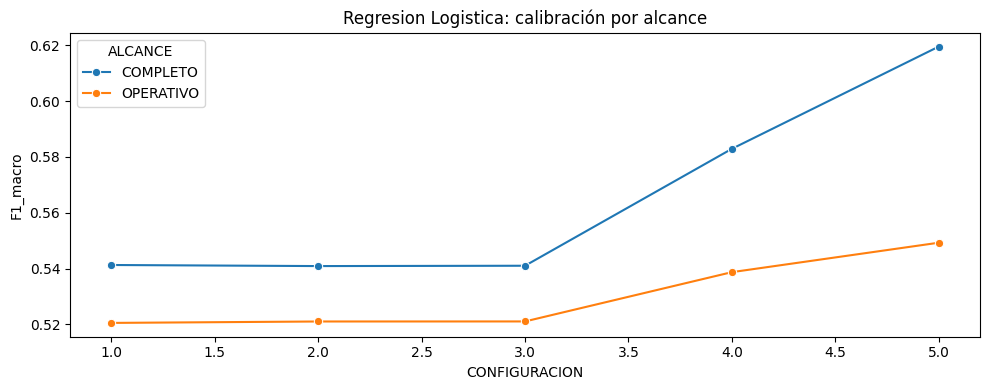

In [22]:
resultados_logistica, comparacion_logistica = evaluar_familia('REGRESION_LOGISTICA')

**Conclusión de regresión logística.** En ambos alcances gana la configuración 5 (`C=0,25`, potencia de peso `0,75`). Con el bloque climático reducido alcanza F1 macro de 0,6195 en completo y 0,5493 en operativo. En el escenario operativo, el clima aumenta levemente el F1 frente a 0,5476 sin clima y reduce el *log loss* de 0,6011 a 0,5950; la mejora de clasificación es pequeña.

### 7.2 Random Forest

Se continúa con Random Forest para evaluar si un ensamble de árboles captura relaciones no lineales. Se varían profundidad, número de árboles, tamaño mínimo de hoja e intensidad del peso de clase.

COMPLETO — configuración 1/6: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


COMPLETO — configuración 2/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


COMPLETO — configuración 3/6: {'n_estimators': 100, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


COMPLETO — configuración 4/6: {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}


COMPLETO — configuración 5/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25}


...

OPERATIVO — configuración 5/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25}


OPERATIVO — configuración 6/6: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.5}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,OPERATIVO,1,"{""n_estimators"": 100, ""max_depth"": 12, ""min_sa...",21.059560,0.790353,0.516513,0.518570,0.779233,0.583184,0.850121,0.538230,0.328046,0.064815
1,RANDOM_FOREST,OPERATIVO,2,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",46.410102,0.809075,0.533740,0.534944,0.801346,0.587072,0.853282,0.511287,0.306310,0.054111
2,RANDOM_FOREST,OPERATIVO,3,"{""n_estimators"": 100, ""max_depth"": 24, ""min_sa...",76.335474,0.812381,0.536840,0.537755,0.805150,0.588541,0.854262,0.501801,0.298957,0.046076
3,RANDOM_FOREST,OPERATIVO,4,"{""n_estimators"": 160, ""max_depth"": 18, ""min_sa...",73.127103,0.810148,0.534713,0.535841,0.802567,0.587847,0.854791,0.509577,0.305014,0.052368
4,RANDOM_FOREST,OPERATIVO,5,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",41.583917,0.810195,0.534850,0.535934,0.802673,0.587205,0.854742,0.512760,0.307418,0.057841
5,RANDOM_FOREST,OPERATIVO,6,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",47.891060,0.813610,0.539266,0.539481,0.807211,0.586520,0.850461,0.516482,0.298960,0.075243


Mejor configuración OPERATIVO: 6 — {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.5}


,MODELO,ALCANCE,CLIMA,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,OPERATIVO,SIN_CLIMA,OPERATIVO_SIN_CLIMA,30.428928,0.814021,0.539854,0.540556,0.807587,0.588063,0.854558,0.518181,0.298844,0.076456
1,RANDOM_FOREST,OPERATIVO,CON_CLIMA,OPERATIVO_CON_CLIMA,47.891060,0.813610,0.539266,0.539481,0.807211,0.586520,0.850461,0.516482,0.298960,0.075243


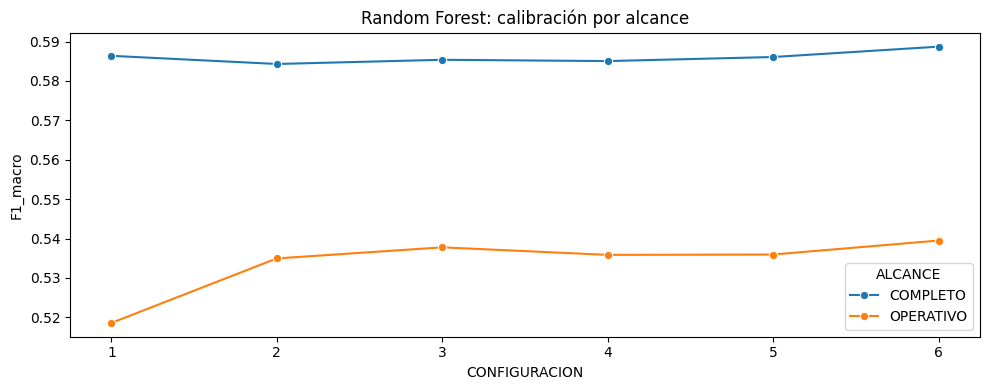

In [23]:
resultados_rf, comparacion_rf = evaluar_familia('RANDOM_FOREST')

**Conclusión de Random Forest.** La configuración 6 es la mejor en ambos alcances. Sin clima obtiene F1 macro de 0,5886 en completo y 0,5406 en operativo. El bloque climático reducido deja prácticamente igual el resultado completo (0,5887), pero disminuye ligeramente el operativo a 0,5395; en ambos casos mejora de forma marginal el *log loss*. Esta familia queda por debajo de XGBoost en completo y de la MLP en operativo.

### 7.3 XGBoost

El tercer bloque evalúa *boosting*. Se combinan número de árboles, profundidad, tasa de aprendizaje, peso mínimo de los nodos e intensidad de ponderación de clases.

COMPLETO — configuración 1/8: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25}


COMPLETO — configuración 2/8: {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}


COMPLETO — configuración 3/8: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25}


COMPLETO — configuración 4/8: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}


COMPLETO — configuración 5/8: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25}


...

OPERATIVO — configuración 7/8: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.5}


OPERATIVO — configuración 8/8: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,OPERATIVO,1,"{""n_estimators"": 160, ""max_depth"": 3, ""learnin...",5.879047,0.815992,0.540129,0.540681,0.809205,0.591896,0.855697,0.498673,0.294558,0.041214
1,XGBOOST,OPERATIVO,2,"{""n_estimators"": 240, ""max_depth"": 3, ""learnin...",8.141310,0.816546,0.541107,0.541730,0.810037,0.595197,0.862609,0.489435,0.288754,0.042700
2,XGBOOST,OPERATIVO,3,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",10.892798,0.817524,0.541650,0.541991,0.810983,0.595129,0.861203,0.492231,0.289009,0.039836
3,XGBOOST,OPERATIVO,4,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.844344,0.818273,0.543678,0.545199,0.812023,0.596963,0.864671,0.486759,0.286654,0.042779
4,XGBOOST,OPERATIVO,5,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",16.036593,0.818381,0.544058,0.545729,0.812174,0.596376,0.864872,0.487444,0.286840,0.043456
5,XGBOOST,OPERATIVO,6,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.606611,0.816849,0.557678,0.564223,0.813191,0.595314,0.863721,0.497584,0.285819,0.038641
6,XGBOOST,OPERATIVO,7,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",15.798391,0.817740,0.555501,0.561443,0.813826,0.594914,0.863085,0.495364,0.284953,0.037174
7,XGBOOST,OPERATIVO,8,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.623843,0.807165,0.580281,0.571155,0.809795,0.591695,0.860999,0.533213,0.300860,0.050767


Mejor configuración OPERATIVO: 8 — {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


,MODELO,ALCANCE,CLIMA,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,OPERATIVO,SIN_CLIMA,OPERATIVO_SIN_CLIMA,8.097213,0.805288,0.585773,0.571898,0.809102,0.591937,0.861470,0.539999,0.303906,0.053059
1,XGBOOST,OPERATIVO,CON_CLIMA,OPERATIVO_CON_CLIMA,9.623843,0.807165,0.580281,0.571155,0.809795,0.591695,0.860999,0.533213,0.300860,0.050767


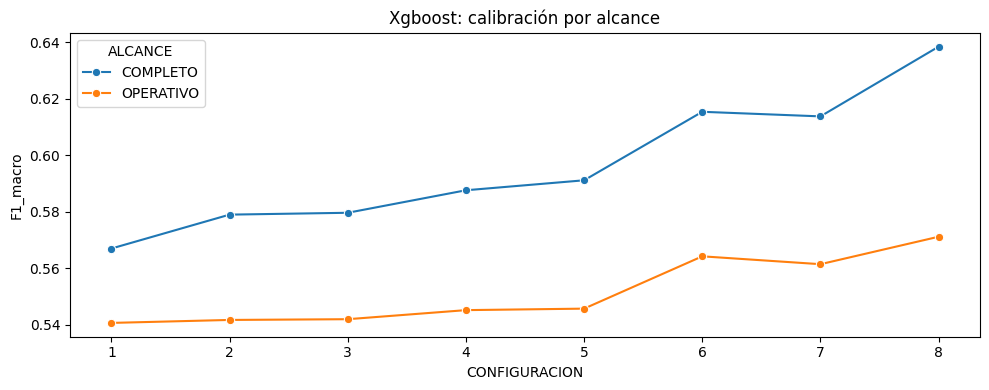

In [24]:
resultados_xgb, comparacion_xgb = evaluar_familia('XGBOOST')

**Conclusión de XGBoost.** La configuración 8 gana en ambos alcances. El modelo completo sin clima obtiene el mejor F1 macro de toda la validación: 0,6401, con *balanced accuracy* de 0,6480. La versión completa con el clima reducido queda muy cerca (0,6384). En el operativo, las versiones sin y con clima también quedan prácticamente empatadas en F1 (0,5719 y 0,5712); el clima reduce el *log loss*, pero no aporta una mejora material de clasificación.

### 7.4 Red neuronal MLP

Finalmente se prueban tres arquitecturas de complejidad creciente. Debido al desbalance, la red se entrena con una muestra balanceada interna y *early stopping*.

COMPLETO — configuración 1/3: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


/Users/leonardoguzman/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


COMPLETO — configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}


COMPLETO — configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,COMPLETO,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",9.910135,0.828511,0.661896,0.596445,0.844811,0.616739,0.885174,0.481149,0.269427,0.044897
1,MLP,COMPLETO,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",80.195497,0.838635,0.633972,0.597635,0.848699,0.613279,0.866986,0.549421,0.263500,0.061026
2,MLP,COMPLETO,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",22.589834,0.855999,0.619345,0.606094,0.859243,0.620285,0.879265,0.479456,0.234424,0.050132


...

OPERATIVO — configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}


OPERATIVO — configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,OPERATIVO,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",5.819898,0.772320,0.638944,0.556410,0.798254,0.581250,0.853274,0.601081,0.342825,0.046287
1,MLP,OPERATIVO,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",21.494720,0.815769,0.601290,0.577054,0.824101,0.587012,0.850115,0.586648,0.299208,0.056936
2,MLP,OPERATIVO,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",19.702814,0.813394,0.593667,0.574474,0.820289,0.585419,0.844809,0.602634,0.301252,0.060001


Mejor configuración OPERATIVO: 2 — {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}


,MODELO,ALCANCE,CLIMA,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,OPERATIVO,SIN_CLIMA,OPERATIVO_SIN_CLIMA,14.980966,0.804539,0.607463,0.570605,0.818002,0.584229,0.849507,0.571851,0.310956,0.052541
1,MLP,OPERATIVO,CON_CLIMA,OPERATIVO_CON_CLIMA,21.494720,0.815769,0.601290,0.577054,0.824101,0.587012,0.850115,0.586648,0.299208,0.056936


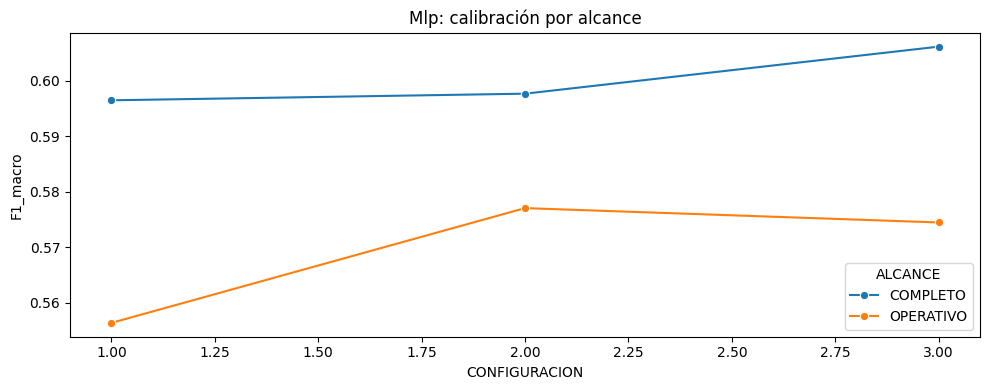

In [25]:
resultados_mlp, comparacion_mlp = evaluar_familia('MLP')

**Conclusión de la MLP.** En el alcance completo gana la arquitectura de tres capas (`128, 64, 32`), mientras que en el operativo gana la de dos capas (`64, 32`). Con el bloque climático reducido alcanza F1 macro de 0,6061 en completo y 0,5771 en operativo, frente a 0,6056 y 0,5706 sin clima usando las mismas configuraciones seleccionadas. La MLP con clima se convierte en el ganador operativo por F1; sin embargo, durante el reajuste final alcanza el límite de 60 iteraciones, por lo que su convergencia requiere cautela.

## 8. Comparación final de modelos, variables disponibles y clima

,MODELO,ALCANCE,CLIMA,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO,SIN_CLIMA,COMPLETO_SIN_CLIMA,10.776481,0.870395,0.647969,0.640133,0.870874,0.647377,0.918857,0.406229,0.221699,0.049900
1,XGBOOST,COMPLETO,CON_CLIMA,COMPLETO_CON_CLIMA,11.339115,0.873918,0.639213,0.638367,0.873611,0.646462,0.918092,0.397377,0.216386,0.042957
2,REGRESION_LOGISTICA,COMPLETO,CON_CLIMA,COMPLETO_CON_CLIMA,20.940115,0.849035,0.621569,0.619479,0.846685,0.641674,0.911058,0.445998,0.240355,0.057509
3,REGRESION_LOGISTICA,COMPLETO,SIN_CLIMA,COMPLETO_SIN_CLIMA,17.284013,0.840457,0.622330,0.615348,0.837697,0.642132,0.911227,0.458731,0.247876,0.054317
4,MLP,COMPLETO,CON_CLIMA,COMPLETO_CON_CLIMA,22.589834,0.855999,0.619345,0.606094,0.859243,0.620285,0.879265,0.479456,0.234424,0.050132
5,MLP,COMPLETO,SIN_CLIMA,COMPLETO_SIN_CLIMA,26.817111,0.856533,0.620861,0.605565,0.861322,0.615530,0.871220,0.528269,0.240559,0.062443
6,RANDOM_FOREST,COMPLETO,CON_CLIMA,COMPLETO_CON_CLIMA,66.127631,0.880889,0.589939,0.588709,0.875922,0.639976,0.912343,0.391225,0.213177,0.056573
7,RANDOM_FOREST,COMPLETO,SIN_CLIMA,COMPLETO_SIN_CLIMA,49.966329,0.880748,0.589819,0.588605,0.875775,0.639882,0.911919,0.395054,0.215471,0.060884
8,MLP,OPERATIVO,CON_CLIMA,OPERATIVO_CON_CLIMA,21.494720,0.815769,0.601290,0.577054,0.824101,0.587012,0.850115,0.586648,0.299208,0.056936
9,XGBOOST,OPERATIVO,SIN_CLIMA,OPERATIVO_SIN_CLIMA,8.097213,0.805288,0.585773,0.571898,0.809102,0.591937,0.861470,0.539999,0.303906,0.053059


,ESCENARIO,MODELO,ALCANCE,CLIMA,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,COMPLETO_CON_CLIMA,XGBOOST,COMPLETO,CON_CLIMA,11.339115,0.873918,0.639213,0.638367,0.873611,0.646462,0.918092,0.397377,0.216386,0.042957
1,COMPLETO_SIN_CLIMA,XGBOOST,COMPLETO,SIN_CLIMA,10.776481,0.870395,0.647969,0.640133,0.870874,0.647377,0.918857,0.406229,0.221699,0.049900
2,OPERATIVO_CON_CLIMA,MLP,OPERATIVO,CON_CLIMA,21.494720,0.815769,0.601290,0.577054,0.824101,0.587012,0.850115,0.586648,0.299208,0.056936
3,OPERATIVO_SIN_CLIMA,XGBOOST,OPERATIVO,SIN_CLIMA,8.097213,0.805288,0.585773,0.571898,0.809102,0.591937,0.861470,0.539999,0.303906,0.053059


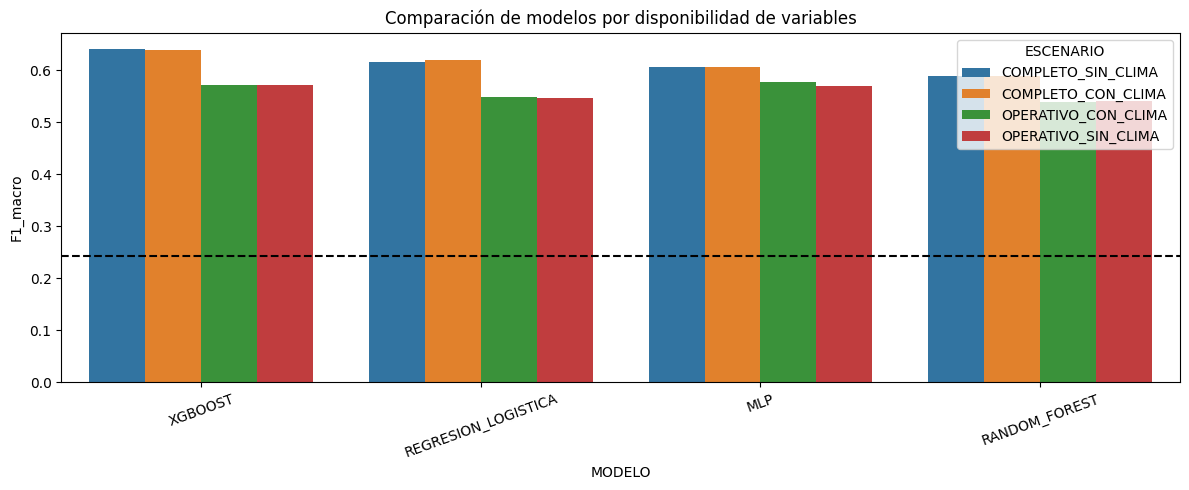

In [26]:
# Consolidar los ganadores locales de los cuatro escenarios
resultados_ajuste = pd.concat(resultados_ajuste_acumulados, ignore_index=True)
resultados_validacion = pd.DataFrame(resultados_validacion).sort_values(
    ['F1_macro', 'Log_Loss'], ascending=[False, True]
).reset_index(drop=True)
display(resultados_validacion)

candidatos = resultados_validacion.query("ALCANCE in ['COMPLETO', 'OPERATIVO']").copy()
mejor_por_escenario = (
    candidatos.sort_values(['F1_macro', 'Balanced_Accuracy', 'Log_Loss'], ascending=[False, False, True])
    .groupby('ESCENARIO', as_index=False).first()
)
display(mejor_por_escenario)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=candidatos, x='MODELO', y='F1_macro', hue='ESCENARIO', ax=ax)
ax.axhline(metricas_baseline['F1_macro'], color='black', linestyle='--', label='Baseline')
ax.set_title('Comparación de modelos por disponibilidad de variables')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Comparación en validación.** El ganador completo es XGBoost sin clima (F1 macro 0,6401) y el operativo es la MLP con el bloque climático reducido (0,5771). El *bootstrap* estima una ventaja promedio de 0,0632 para las variables completas, con IC 95 % entre 0,0581 y 0,0685.

Dentro de la MLP operativa, agregar el clima reducido aumenta el F1 macro en 0,0063 (IC 95 %: 0,0030–0,0095), pero disminuye el *balanced accuracy* en 0,0066 y aumenta el *log loss* en 0,0148. Por tanto, el clima gana bajo el criterio principal de selección, aunque el beneficio es pequeño y presenta un compromiso con otras métricas.

In [27]:
# Elegir un ganador completo y uno operativo sin consultar prueba
ganadores_alcance = (
    candidatos.sort_values(['F1_macro', 'Balanced_Accuracy', 'Log_Loss'], ascending=[False, False, True])
    .groupby('ALCANCE', as_index=False).first()
)
display(ganadores_alcance)

GANADORES = {}
for _, fila in ganadores_alcance.iterrows():
    alcance = fila['ALCANCE']
    GANADORES[alcance] = {
        'modelo': fila['MODELO'], 'escenario': fila['ESCENARIO'],
        'parametros': mejores_parametros[(fila['MODELO'], alcance)]
    }
print(json.dumps(GANADORES, ensure_ascii=False, indent=2))

# El diseño operativo dirige los diagnósticos y el backtesting
NOMBRE_GANADOR = GANADORES['OPERATIVO']['modelo']
ESCENARIO_GANADOR = GANADORES['OPERATIVO']['escenario']
PARAMETROS_GANADOR = GANADORES['OPERATIVO']['parametros']

,ALCANCE,MODELO,CLIMA,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,COMPLETO,XGBOOST,SIN_CLIMA,COMPLETO_SIN_CLIMA,10.776481,0.870395,0.647969,0.640133,0.870874,0.647377,0.918857,0.406229,0.221699,0.049900
1,OPERATIVO,MLP,CON_CLIMA,OPERATIVO_CON_CLIMA,21.494720,0.815769,0.601290,0.577054,0.824101,0.587012,0.850115,0.586648,0.299208,0.056936


{
  "COMPLETO": {
    "modelo": "XGBOOST",
    "escenario": "COMPLETO_SIN_CLIMA",
    "parametros": {
      "n_estimators": 240,
      "max_depth": 5,
      "learning_rate": 0.08,
      "min_child_weight": 10,
      "potencia_peso": 0.75
    }
  },
  "OPERATIVO": {
    "modelo": "MLP",
    "escenario": "OPERATIVO_CON_CLIMA",
    "parametros": {
      "hidden_layer_sizes": [
        64,
        32
      ],
      "alpha": 0.001,
      "learning_rate_init": 0.001
    }
  }
}


## 9. Incertidumbre del aporte climático

In [28]:
# Bootstrap pareado: impacto de usar variables no disponibles y del clima
def indices_bootstrap_estratificado(y, rng):
    return np.concatenate([
        rng.choice(np.flatnonzero(y == clase), size=np.sum(y == clase), replace=True)
        for clase in np.unique(y)
    ])

def bootstrap_delta(y, proba_base, proba_alternativa, repeticiones=250, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    registros = []
    for _ in range(repeticiones):
        indices = indices_bootstrap_estratificado(y, rng)
        m_base = calcular_metricas(y[indices], proba_base[indices])
        m_alt = calcular_metricas(y[indices], proba_alternativa[indices])
        registros.append({
            'F1_macro': m_alt['F1_macro'] - m_base['F1_macro'],
            'Balanced_Accuracy': m_alt['Balanced_Accuracy'] - m_base['Balanced_Accuracy'],
            'Log_Loss': m_base['Log_Loss'] - m_alt['Log_Loss'],
        })
    muestras = pd.DataFrame(registros)
    return pd.DataFrame({'DELTA_PROMEDIO': muestras.mean(), 'IC95_INFERIOR': muestras.quantile(0.025), 'IC95_SUPERIOR': muestras.quantile(0.975)})

g_completo = GANADORES['COMPLETO']
g_operativo = GANADORES['OPERATIVO']
proba_completo_val = probabilidades_validacion[(g_completo['modelo'], g_completo['escenario'])]
proba_operativo_val = probabilidades_validacion[(g_operativo['modelo'], g_operativo['escenario'])]

# Positivo significa que agregar las variables no disponibles mejora
impacto_variables = bootstrap_delta(y_val, proba_operativo_val, proba_completo_val)
display(impacto_variables)

# Comparación climática dentro del mismo modelo y alcance operativo
escenario_op_con = 'OPERATIVO_CON_CLIMA'
escenario_op_sin = 'OPERATIVO_SIN_CLIMA'
proba_op_con = probabilidades_validacion[(NOMBRE_GANADOR, escenario_op_con)]
proba_op_sin = probabilidades_validacion[(NOMBRE_GANADOR, escenario_op_sin)]
impacto_clima_operativo = bootstrap_delta(y_val, proba_op_sin, proba_op_con)
display(impacto_clima_operativo)

,DELTA_PROMEDIO,IC95_INFERIOR,IC95_SUPERIOR
F1_macro,0.063245,0.058085,0.068504
Balanced_Accuracy,0.046916,0.039839,0.054003
Log_Loss,0.180323,0.175722,0.184874


,DELTA_PROMEDIO,IC95_INFERIOR,IC95_SUPERIOR
F1_macro,0.006273,0.002986,0.009538
Balanced_Accuracy,-0.006587,-0.014694,0.000709
Log_Loss,-0.014763,-0.018929,-0.010445


## 10. Backtesting temporal del diseño ganador

El *backtesting* del diseño operativo ganador produce F1 macro de 0,5639 en 2017–2018 y 0,5694 en 2019–2020. La cercanía entre ambos periodos es una señal favorable de estabilidad histórica, aunque no sustituye la prueba final.

In [29]:
VENTANAS_BACKTEST = [
    {'ENTRENA_HASTA': 2016, 'VALIDA_DESDE': 2017, 'VALIDA_HASTA': 2018},
    {'ENTRENA_HASTA': 2018, 'VALIDA_DESDE': 2019, 'VALIDA_HASTA': 2020},
]

resultados_backtest = []
for ventana in VENTANAS_BACKTEST:
    mascara_bt_train = datos_modelo['ANIO'] <= ventana['ENTRENA_HASTA']
    mascara_bt_val = datos_modelo['ANIO'].between(ventana['VALIDA_DESDE'], ventana['VALIDA_HASTA'])
    X_bt_train, y_bt_train = construir_xy(mascara_bt_train, ESCENARIO_GANADOR)
    X_bt_val, y_bt_val = construir_xy(mascara_bt_val, ESCENARIO_GANADOR)
    indices_bt = indices_muestra_ajuste(y_bt_train)
    modelo_bt, segundos = ajustar_modelo(
        NOMBRE_GANADOR, ESCENARIO_GANADOR, PARAMETROS_GANADOR,
        X_bt_train.iloc[indices_bt].reset_index(drop=True), y_bt_train[indices_bt]
    )
    proba_bt = ordenar_probabilidades(modelo_bt, X_bt_val, clases_codificadas)
    resultados_backtest.append({
        **ventana, 'FILAS_ENTRENAMIENTO': len(indices_bt),
        'FILAS_VALIDACION': len(y_bt_val), 'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_bt_val, proba_bt),
    })

resultados_backtest = pd.DataFrame(resultados_backtest)
display(resultados_backtest)

,ENTRENA_HASTA,VALIDA_DESDE,VALIDA_HASTA,FILAS_ENTRENAMIENTO,FILAS_VALIDACION,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2016,2017,2018,300000,278088,15.335715,0.848253,0.612296,0.563929,0.863974,0.571334,0.855943,0.501523,0.252940,0.040134
1,2018,2019,2020,300000,231349,18.768975,0.849072,0.609128,0.569354,0.863623,0.579736,0.865865,0.506724,0.252103,0.041952


## 11. Reajuste y comparación final no tocada

Los ganadores completo y operativo se reajustan con una muestra común, estratificada y reproducible de hasta 600.000 actores de desarrollo. Este límite evita que el reajuste de ensambles sobre 1,85 millones de filas bloquee la ejecución durante horas. La selección permanece cerrada en validación y la prueba 2024–2026 no participa en el muestreo.

In [30]:
mascara_desarrollo = datos_modelo['ANIO'] <= ANIO_FIN_VALIDACION
resultados_test = []
modelos_finales = {}
probabilidades_finales = {}

# Construir una muestra final común para evitar reajustes prohibitivos
_, y_desarrollo_referencia = construir_xy(mascara_desarrollo, 'COMPLETO_CON_CLIMA')
indices_desarrollo = indices_muestra_ajuste(
    y_desarrollo_referencia, tamano=600_000, semilla=SEMILLA + 100
)
print(f'Muestra de reajuste final: {len(indices_desarrollo):,} de {len(y_desarrollo_referencia):,} actores')

baseline_final = DummyClassifier(strategy='prior', random_state=SEMILLA)
baseline_final.fit(np.zeros((len(indices_desarrollo), 1)), y_desarrollo_referencia[indices_desarrollo])
proba_baseline_test = ordenar_probabilidades(baseline_final, np.zeros((mascara_test.sum(), 1)), clases_codificadas)
metricas_baseline_test = calcular_metricas(y_test, proba_baseline_test)
resultados_test.append({'ALCANCE': 'BASELINE', 'MODELO': 'BASELINE_PRIOR', 'ESCENARIO': 'SIN_PREDICTORES', **metricas_baseline_test})

for alcance in ['COMPLETO', 'OPERATIVO']:
    ganador = GANADORES[alcance]
    X_desarrollo_alcance, y_desarrollo = construir_xy(mascara_desarrollo, ganador['escenario'])
    X_test_alcance, _ = construir_xy(mascara_test, ganador['escenario'])
    X_reajuste = X_desarrollo_alcance.iloc[indices_desarrollo].reset_index(drop=True)
    y_reajuste = y_desarrollo[indices_desarrollo]
    print(f'Reajustando {alcance}: {ganador["modelo"]} / {ganador["escenario"]} con {len(y_reajuste):,} registros...')
    modelo, segundos = ajustar_modelo(
        ganador['modelo'], ganador['escenario'], ganador['parametros'],
        X_reajuste, y_reajuste
    )
    proba = ordenar_probabilidades(modelo, X_test_alcance, clases_codificadas)
    modelos_finales[alcance] = modelo
    probabilidades_finales[alcance] = proba
    resultados_test.append({
        'ALCANCE': alcance, 'MODELO': ganador['modelo'], 'ESCENARIO': ganador['escenario'],
        'SEGUNDOS_AJUSTE': segundos, **calcular_metricas(y_test, proba)
    })

comparacion_test = pd.DataFrame(resultados_test)
display(comparacion_test)

# Variables de referencia para el diagnóstico del modelo operativo
modelo_final = modelos_finales['OPERATIVO']
probabilidades_test = probabilidades_finales['OPERATIVO']
prediccion_test = clases_codificadas[np.argmax(probabilidades_test, axis=1)]
metricas_test = calcular_metricas(y_test, probabilidades_test)
X_desarrollo_completo, y_desarrollo = construir_xy(mascara_desarrollo, ESCENARIO_GANADOR)
X_desarrollo = X_desarrollo_completo.iloc[indices_desarrollo].reset_index(drop=True)
X_test, _ = construir_xy(mascara_test, ESCENARIO_GANADOR)

Muestra de reajuste final: 600,000 de 1,844,909 actores


Reajustando COMPLETO: XGBOOST / COMPLETO_SIN_CLIMA con 600,000 registros...


Reajustando OPERATIVO: MLP / OPERATIVO_CON_CLIMA con 600,000 registros...


/Users/leonardoguzman/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


,ALCANCE,MODELO,ESCENARIO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins,SEGUNDOS_AJUSTE
0,BASELINE,BASELINE_PRIOR,SIN_PREDICTORES,0.310211,0.333333,0.157843,0.146894,0.333333,0.500000,1.166963,0.853648,0.452782,NaN
1,COMPLETO,XGBOOST,COMPLETO_SIN_CLIMA,0.834515,0.656554,0.634035,0.838494,0.635715,0.889296,0.499809,0.279936,0.056024,20.481896
2,OPERATIVO,MLP,OPERATIVO_CON_CLIMA,0.717121,0.607783,0.538058,0.751385,0.557235,0.803689,0.854706,0.446304,0.140682,59.368508


In [31]:
# Intervalos de confianza del 95 % mediante bootstrap estratificado
def bootstrap_metricas(y, probabilidades, repeticiones=300, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    registros = []
    for _ in range(repeticiones):
        indices = indices_bootstrap_estratificado(y, rng)
        registros.append(calcular_metricas(y[indices], probabilidades[indices]))
    muestras = pd.DataFrame(registros)
    return pd.DataFrame({
        'ESTIMACION_TEST': pd.Series(metricas_test),
        'IC95_INFERIOR': muestras.quantile(0.025),
        'IC95_SUPERIOR': muestras.quantile(0.975),
    })

intervalos_test = bootstrap_metricas(y_test, probabilidades_test)
display(intervalos_test)

,ESTIMACION_TEST,IC95_INFERIOR,IC95_SUPERIOR
Accuracy,0.717121,0.714043,0.720318
Balanced_Accuracy,0.607783,0.598875,0.615075
F1_macro,0.538058,0.534975,0.541028
F1_weighted,0.751385,0.748505,0.754330
PR_AUC_macro,0.557235,0.554763,0.560349
ROC_AUC_OVR_macro,0.803689,0.799433,0.808218
Log_Loss,0.854706,0.843617,0.865577
Brier_multiclase,0.446304,0.441597,0.451133
ECE_10_bins,0.140682,0.137863,0.143800


**Resultado de la prueba temporal.** En 2024–2026, XGBoost completo sin clima obtiene F1 macro de 0,6340. La MLP operativa con el bloque climático reducido alcanza 0,5381 (IC 95 %: 0,5350–0,5410), *balanced accuracy* de 0,6078 y *accuracy* de 0,7171. Supera la línea base de 0,1578 en +0,3802 de F1 macro.

El modelo completo aventaja al operativo en 0,0960 fuera de muestra. La MLP operativa presenta *log loss* de 0,8547 y ECE de 0,1407, por lo que sus probabilidades aún requieren cautela. Frente a la corrida anterior sin `ZONA_CIUDAD`, el F1 macro aumenta de 0,5327 a 0,5381 en el alcance operativo y de 0,6296 a 0,6340 en el completo.

## 12. Diagnóstico por clase y análisis de errores

,precision,recall,f1-score,support
HERIDO,0.878351,0.691967,0.774098,50764.000000
ILESO,0.698898,0.795831,0.744221,23505.000000
MUERTO,0.055913,0.335553,0.095854,1502.000000
accuracy,0.717121,0.717121,0.717121,0.717121
macro avg,0.544387,0.607783,0.538058,75771.000000
weighted avg,0.806379,0.717121,0.751385,75771.000000


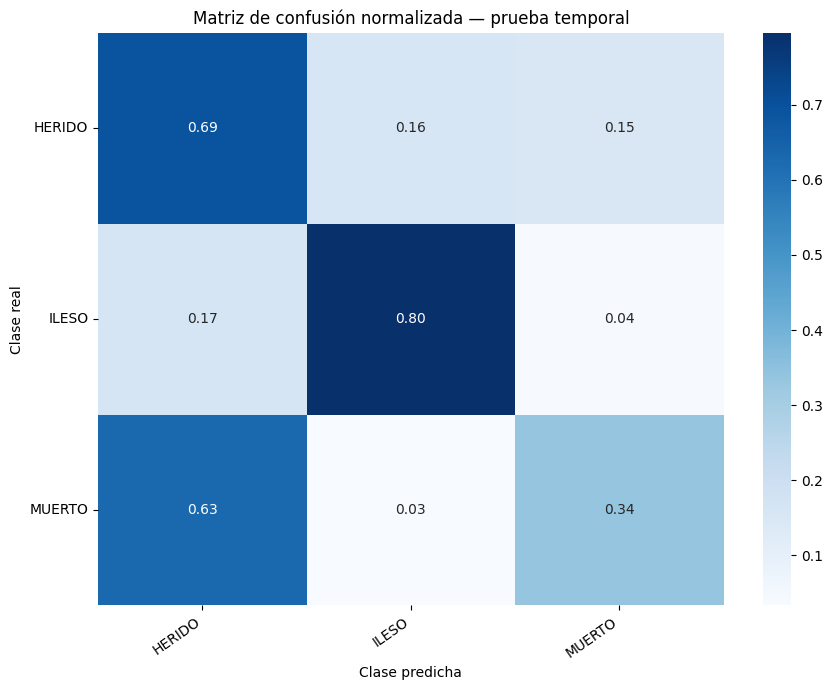

In [32]:
nombres_estados = [catalogo_estados[codigo] for codigo in encoder_objetivo.classes_]
reporte_clases = pd.DataFrame(classification_report(
    y_test, prediccion_test, labels=clases_codificadas,
    target_names=nombres_estados, output_dict=True, zero_division=0
)).T
display(reporte_clases)

matriz = confusion_matrix(y_test, prediccion_test, labels=clases_codificadas, normalize='true')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=nombres_estados, yticklabels=nombres_estados, ax=ax)
ax.set_title('Matriz de confusión normalizada — prueba temporal')
ax.set_xlabel('Clase predicha')
ax.set_ylabel('Clase real')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura por estado del modelo operativo.** `HERIDO` obtiene F1 de 0,7741 y `ILESO` de 0,7442. Ambas clases mayoritarias se distinguen con un desempeño considerablemente superior al de `MUERTO`.

`MUERTO` sigue siendo el problema central: alcanza *recall* de 0,3356, precisión de 0,0559 y F1 de 0,0959. En otras palabras, identifica una parte de las muertes, pero a costa de una cantidad alta de falsos positivos. Retirar `SIN INFORMACION`, incorporar la zona y depurar el bloque climático no hace confiable por sí sola la predicción de mortalidad.

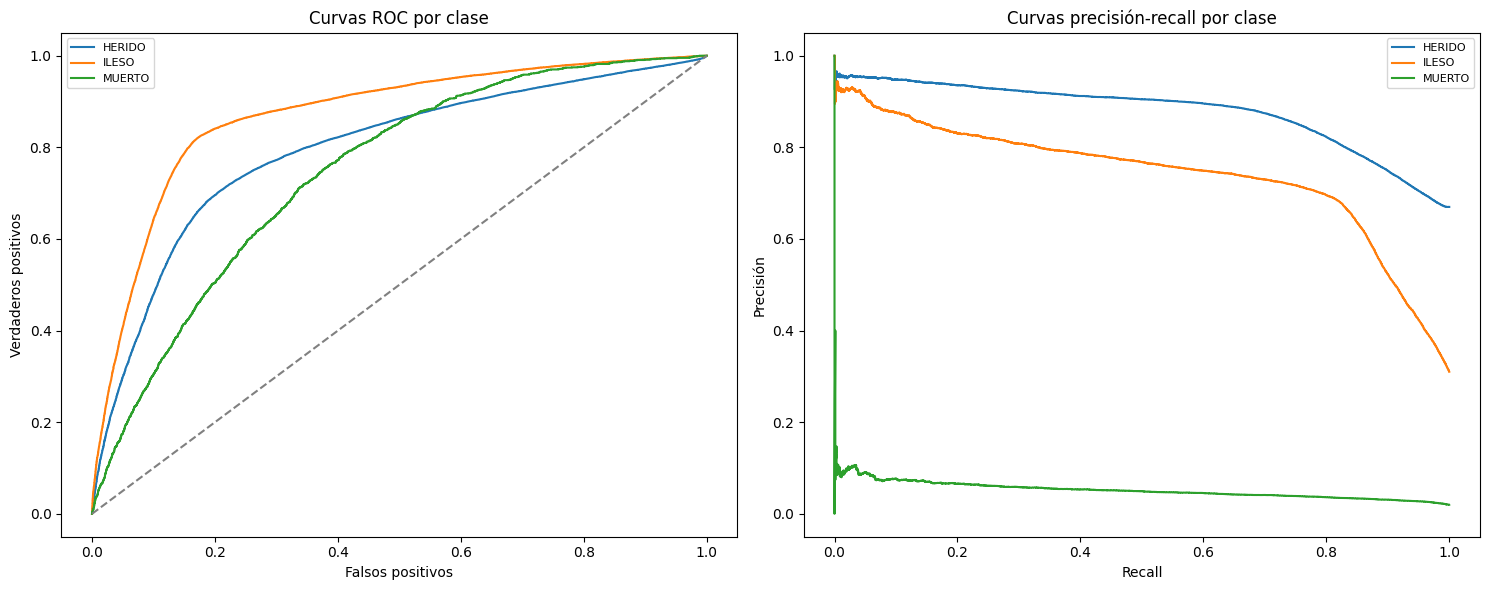

In [33]:
# Curvas ROC y precisión-recall uno contra el resto
y_test_bin = LabelBinarizer().fit(clases_codificadas).transform(y_test)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for posicion, nombre_clase in enumerate(nombres_estados):
    fpr, tpr, _ = roc_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    precision, recall, _ = precision_recall_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    axes[0].plot(fpr, tpr, label=nombre_clase)
    axes[1].plot(recall, precision, label=nombre_clase)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(title='Curvas ROC por clase', xlabel='Falsos positivos', ylabel='Verdaderos positivos')
axes[1].set(title='Curvas precisión-recall por clase', xlabel='Recall', ylabel='Precisión')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
# Estabilidad por año dentro del periodo de prueba
anios_test = datos_modelo.loc[mascara_test, 'ANIO'].reset_index(drop=True)
metricas_por_anio = []
for anio in sorted(anios_test.unique()):
    mascara_anio = anios_test.eq(anio).to_numpy()
    metricas_anio = calcular_metricas(y_test[mascara_anio], probabilidades_test[mascara_anio])
    metricas_por_anio.append({'ANIO': int(anio), 'FILAS': int(mascara_anio.sum()), **metricas_anio})
metricas_por_anio = pd.DataFrame(metricas_por_anio)
display(metricas_por_anio)

,ANIO,FILAS,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2024,32698,0.715518,0.605636,0.532395,0.750283,0.549463,0.799850,0.859244,0.449649,0.140145
1,2025,29030,0.716431,0.614900,0.540185,0.750449,0.563080,0.810210,0.842653,0.445116,0.141464
2,2026,14043,0.722282,0.600051,0.546378,0.756181,0.564349,0.799777,0.869054,0.440974,0.141423


,BIN,CASOS,CONFIANZA_MEDIA,EXACTITUD
0,"(-0.001, 0.1]",0,NaN,NaN
1,"(0.1, 0.2]",0,NaN,NaN
2,"(0.2, 0.3]",0,NaN,NaN
3,"(0.3, 0.4]",65,0.381933,0.369231
4,"(0.4, 0.5]",756,0.470187,0.480159
5,"(0.5, 0.6]",5284,0.550073,0.522710
6,"(0.6, 0.7]",6284,0.652205,0.593253
7,"(0.7, 0.8]",8653,0.753373,0.661967
8,"(0.8, 0.9]",14755,0.855552,0.718062
9,"(0.9, 1.0]",39974,0.961966,0.778931


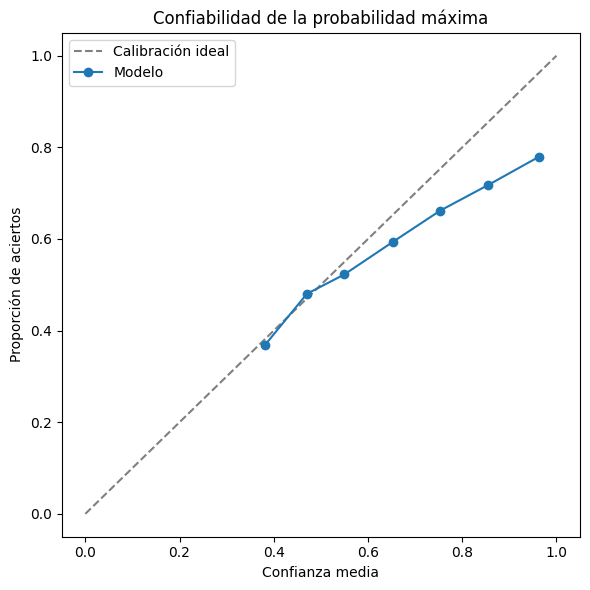

In [35]:
# Confiabilidad de la probabilidad máxima
confianza = probabilidades_test.max(axis=1)
acierto = (prediccion_test == y_test).astype(int)
bins = pd.cut(confianza, bins=np.linspace(0, 1, 11), include_lowest=True)
tabla_calibracion = (
    pd.DataFrame({'BIN': bins, 'CONFIANZA': confianza, 'ACIERTO': acierto})
    .groupby('BIN', observed=False)
    .agg(CASOS=('ACIERTO', 'size'), CONFIANZA_MEDIA=('CONFIANZA', 'mean'), EXACTITUD=('ACIERTO', 'mean'))
    .reset_index()
)
display(tabla_calibracion)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración ideal')
ax.plot(tabla_calibracion['CONFIANZA_MEDIA'], tabla_calibracion['EXACTITUD'], marker='o', label='Modelo')
ax.set(title='Confiabilidad de la probabilidad máxima', xlabel='Confianza media', ylabel='Proporción de aciertos')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Experimento de sensibilidad: partición aleatoria por accidente

La evaluación temporal se mantiene como estimación principal porque simula la predicción sobre periodos futuros. Como contraste, se construye una partición aleatoria usando todos los años disponibles. La asignación se realiza por `ACCIDENTE_ID`, de modo que todos los actores de un mismo accidente permanezcan juntos y no exista fuga de información entre entrenamiento y prueba.

Para aislar el efecto de la partición, se conserva el modelo operativo, sus variables y los hiperparámetros seleccionados previamente con 2021–2023. También se mantiene una cantidad de accidentes de prueba semejante a la del corte temporal y `ANIO` continúa fuera de los predictores. El resultado aleatorio se interpreta como análisis de sensibilidad y no se utiliza para cambiar el modelo ganador.

/Users/leonardoguzman/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


,PARTICION,FILAS,ACCIDENTES,FECHA_MINIMA,FECHA_MAXIMA,CLASES_PRESENTES
0,ENTRENAMIENTO_ALEATORIO,1852391,862157,2007-01-01 00:00:00,2026-07-20 08:45:00,3
1,PRUEBA_ALEATORIA,68289,31862,2007-01-01 00:55:00,2026-07-08 18:40:00,3


,ENTRENAMIENTO_ALEATORIO,PRUEBA_ALEATORIA
HERIDO,24.738,24.597
ILESO,74.451,74.634
MUERTO,0.811,0.769


,ESQUEMA,FILAS_PRUEBA,ACCIDENTES_PRUEBA,F1_BASELINE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins,DELTA_F1_VS_BASELINE
0,TEMPORAL_2024_2026,75771,31862,0.157843,0.717121,0.607783,0.538058,0.751385,0.557235,0.803689,0.854706,0.446304,0.140682,0.380215
1,ALEATORIA_POR_ACCIDENTE,68289,31862,0.284916,0.822768,0.700193,0.566596,0.847134,0.582496,0.882494,0.548250,0.283742,0.043272,0.281679


,TEMPORAL_2024_2026,ALEATORIA_POR_ACCIDENTE
HERIDO,0.774098,0.679333
ILESO,0.744221,0.910024
MUERTO,0.095854,0.110429


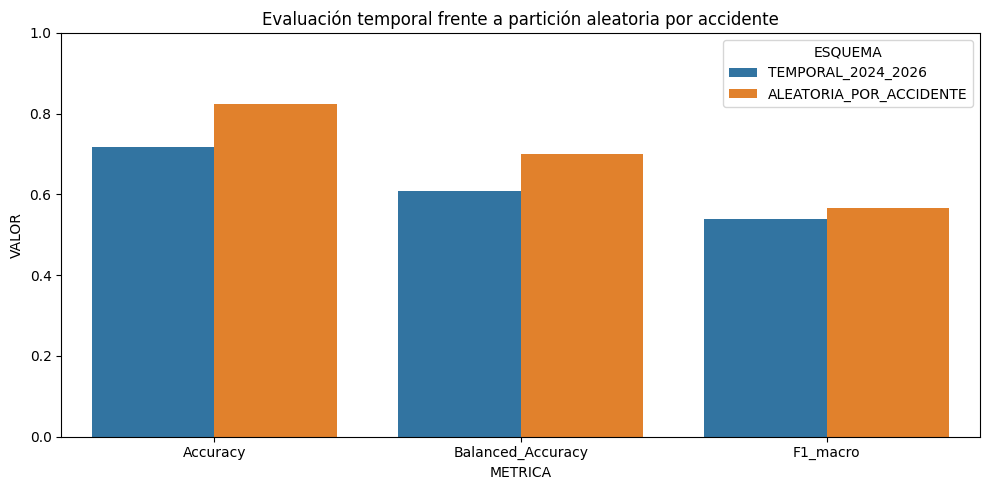

Diferencia de F1 macro aleatorio - temporal: +0.0285
Diferencia de F1 de MUERTO aleatorio - temporal: +0.0146
La partición aleatoria produce una estimación sensiblemente más optimista. La partición temporal debe conservarse como evaluación principal.
Tiempo de ajuste aleatorio: 30.7 segundos


In [36]:
# Mantener una fracción de accidentes de prueba comparable al corte temporal
fraccion_prueba_aleatoria = (
    datos_modelo.loc[mascara_test, 'ACCIDENTE_ID'].nunique()
    / datos_modelo['ACCIDENTE_ID'].nunique()
)
separador_aleatorio = GroupShuffleSplit(
    n_splits=1, test_size=fraccion_prueba_aleatoria, random_state=SEMILLA
)
indices_entrenamiento_aleatorio, indices_prueba_aleatoria = next(
    separador_aleatorio.split(
        datos_modelo, groups=datos_modelo['ACCIDENTE_ID'].to_numpy()
    )
)
mascara_entrenamiento_aleatorio = np.zeros(len(datos_modelo), dtype=bool)
mascara_prueba_aleatoria = np.zeros(len(datos_modelo), dtype=bool)
mascara_entrenamiento_aleatorio[indices_entrenamiento_aleatorio] = True
mascara_prueba_aleatoria[indices_prueba_aleatoria] = True

accidentes_entrenamiento_aleatorio = set(
    datos_modelo.loc[mascara_entrenamiento_aleatorio, 'ACCIDENTE_ID']
)
accidentes_prueba_aleatoria = set(
    datos_modelo.loc[mascara_prueba_aleatoria, 'ACCIDENTE_ID']
)
assert accidentes_entrenamiento_aleatorio.isdisjoint(accidentes_prueba_aleatoria)
assert (mascara_entrenamiento_aleatorio ^ mascara_prueba_aleatoria).all()

X_entrenamiento_aleatorio, y_entrenamiento_aleatorio = construir_xy(
    mascara_entrenamiento_aleatorio, ESCENARIO_GANADOR
)
X_prueba_aleatoria, y_prueba_aleatoria = construir_xy(
    mascara_prueba_aleatoria, ESCENARIO_GANADOR
)
indices_ajuste_aleatorio = indices_muestra_ajuste(
    y_entrenamiento_aleatorio, tamano=len(indices_desarrollo),
    semilla=SEMILLA + 200
)
modelo_aleatorio, segundos_aleatorio = ajustar_modelo(
    NOMBRE_GANADOR, ESCENARIO_GANADOR, PARAMETROS_GANADOR,
    X_entrenamiento_aleatorio.iloc[indices_ajuste_aleatorio].reset_index(drop=True),
    y_entrenamiento_aleatorio[indices_ajuste_aleatorio]
)
probabilidades_aleatorias = ordenar_probabilidades(
    modelo_aleatorio, X_prueba_aleatoria, clases_codificadas
)
prediccion_aleatoria = clases_codificadas[
    np.argmax(probabilidades_aleatorias, axis=1)
]
metricas_aleatorias = calcular_metricas(
    y_prueba_aleatoria, probabilidades_aleatorias
)

baseline_aleatorio = DummyClassifier(strategy='prior', random_state=SEMILLA)
baseline_aleatorio.fit(
    np.zeros((len(indices_ajuste_aleatorio), 1)),
    y_entrenamiento_aleatorio[indices_ajuste_aleatorio]
)
probabilidades_baseline_aleatorio = ordenar_probabilidades(
    baseline_aleatorio, np.zeros((len(y_prueba_aleatoria), 1)),
    clases_codificadas
)
metricas_baseline_aleatorio = calcular_metricas(
    y_prueba_aleatoria, probabilidades_baseline_aleatorio
)

resumen_particion_aleatoria = []
for nombre, mascara, y_particion in [
    ('ENTRENAMIENTO_ALEATORIO', mascara_entrenamiento_aleatorio, y_entrenamiento_aleatorio),
    ('PRUEBA_ALEATORIA', mascara_prueba_aleatoria, y_prueba_aleatoria),
]:
    resumen_particion_aleatoria.append({
        'PARTICION': nombre,
        'FILAS': int(mascara.sum()),
        'ACCIDENTES': datos_modelo.loc[mascara, 'ACCIDENTE_ID'].nunique(),
        'FECHA_MINIMA': datos_modelo.loc[mascara, 'FECHA_HORA'].min(),
        'FECHA_MAXIMA': datos_modelo.loc[mascara, 'FECHA_HORA'].max(),
        'CLASES_PRESENTES': len(np.unique(y_particion)),
    })
resumen_particion_aleatoria = pd.DataFrame(resumen_particion_aleatoria)
display(resumen_particion_aleatoria)

distribucion_aleatoria = pd.DataFrame({
    'ENTRENAMIENTO_ALEATORIO': pd.Series(y_entrenamiento_aleatorio).value_counts(normalize=True),
    'PRUEBA_ALEATORIA': pd.Series(y_prueba_aleatoria).value_counts(normalize=True),
}).fillna(0).reindex(clases_codificadas, fill_value=0)
distribucion_aleatoria.index = nombres_estados
display((100 * distribucion_aleatoria).round(3))

comparacion_particiones = pd.DataFrame([
    {
        'ESQUEMA': 'TEMPORAL_2024_2026',
        'FILAS_PRUEBA': len(y_test),
        'ACCIDENTES_PRUEBA': datos_modelo.loc[mascara_test, 'ACCIDENTE_ID'].nunique(),
        'F1_BASELINE': metricas_baseline_test['F1_macro'],
        **metricas_test,
    },
    {
        'ESQUEMA': 'ALEATORIA_POR_ACCIDENTE',
        'FILAS_PRUEBA': len(y_prueba_aleatoria),
        'ACCIDENTES_PRUEBA': len(accidentes_prueba_aleatoria),
        'F1_BASELINE': metricas_baseline_aleatorio['F1_macro'],
        **metricas_aleatorias,
    },
])
comparacion_particiones['DELTA_F1_VS_BASELINE'] = (
    comparacion_particiones['F1_macro']
    - comparacion_particiones['F1_BASELINE']
)
display(comparacion_particiones)

reporte_clases_aleatorio = pd.DataFrame(classification_report(
    y_prueba_aleatoria, prediccion_aleatoria, labels=clases_codificadas,
    target_names=nombres_estados, output_dict=True, zero_division=0
)).T
comparacion_f1_estado = pd.DataFrame({
    'TEMPORAL_2024_2026': reporte_clases.loc[nombres_estados, 'f1-score'],
    'ALEATORIA_POR_ACCIDENTE': reporte_clases_aleatorio.loc[nombres_estados, 'f1-score'],
})
display(comparacion_f1_estado)

metricas_grafico = comparacion_particiones.melt(
    id_vars='ESQUEMA',
    value_vars=['Accuracy', 'Balanced_Accuracy', 'F1_macro'],
    var_name='METRICA', value_name='VALOR'
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metricas_grafico, x='METRICA', y='VALOR', hue='ESQUEMA', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Evaluación temporal frente a partición aleatoria por accidente')
plt.tight_layout()
plt.show()

delta_f1_aleatorio = metricas_aleatorias['F1_macro'] - metricas_test['F1_macro']
delta_f1_muerto_aleatorio = (
    reporte_clases_aleatorio.loc['MUERTO', 'f1-score']
    - reporte_clases.loc['MUERTO', 'f1-score']
)
if delta_f1_aleatorio > 0.02:
    conclusion_particion = (
        'La partición aleatoria produce una estimación sensiblemente más optimista. '
        'La partición temporal debe conservarse como evaluación principal.'
    )
elif delta_f1_aleatorio < -0.02:
    conclusion_particion = (
        'La partición aleatoria no mejora el resultado; la evaluación temporal sigue '
        'siendo preferible por representar el uso futuro.'
    )
else:
    conclusion_particion = (
        'Los dos esquemas presentan F1 macro similar, señal favorable de estabilidad; '
        'aun así, la partición temporal representa mejor el uso futuro.'
    )
print(f'Diferencia de F1 macro aleatorio - temporal: {delta_f1_aleatorio:+.4f}')
print(f'Diferencia de F1 de MUERTO aleatorio - temporal: {delta_f1_muerto_aleatorio:+.4f}')
print(conclusion_particion)
print(f'Tiempo de ajuste aleatorio: {segundos_aleatorio:,.1f} segundos')

### Interpretación metodológica

La partición aleatoria por accidente obtiene un F1 macro de 0,5666, frente a 0,5381 con la partición temporal (+0,0285). También alcanza mayor exactitud (0,8228 frente a 0,7171), menor *log loss* (0,5483 frente a 0,8547) y un F1 algo mayor para `MUERTO` (0,1104 frente a 0,0959). Sin embargo, la partición aleatoria mezcla observaciones de todos los años y conserva proporciones casi idénticas entre entrenamiento y prueba: en su prueba predominan `ILESO` (74,63 %) y `HERIDO` (24,60 %), mientras que en la prueba temporal 2024–2026 `HERIDO` pasa a representar 67,00 % e `ILESO` 31,02 %. Además, aunque sus métricas absolutas son mayores, su mejora sobre la línea base propia es menor (0,2817 frente a 0,3802). Por tanto, el resultado aleatorio se interpreta como una medida de sensibilidad bajo una distribución mezclada y no como evidencia de generalización hacia años futuros; la partición temporal se conserva como evaluación principal.

## 14. Importancia de variables operativas

`CLASE_VEHICULO` domina la importancia por permutación, seguida por `GENERO` y las variables temporales. `ZONA_CIUDAD` ocupa el sexto lugar, con una disminución media de 0,0140 en F1 macro al permutarla; aporta una señal espacial secundaria y supera individualmente a `CELDA_X` y `CELDA_Y`.

,VARIABLE,IMPORTANCIA_MEDIA,DESVIACION
0,CLASE_VEHICULO,0.163175,0.004552
1,GENERO,0.045455,0.000896
2,EDAD,0.017152,0.001143
3,MES,0.010630,0.004524
4,MES_SIN,0.009923,0.003182
5,SERVICIO_VEHICULO,0.009841,0.002835
6,ZONA_CIUDAD,0.007355,0.003658
7,DIA_SEMANA_SIN,0.006584,0.003122
8,MES_COS,0.005634,0.002709
9,DIA_SEMANA,0.005389,0.004066


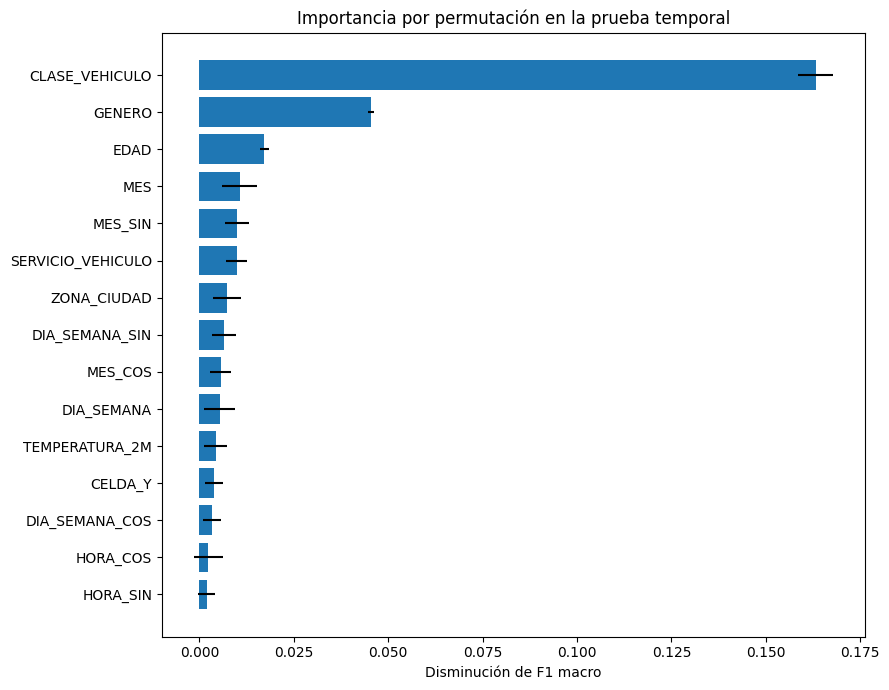

In [37]:
# Importancia por permutación sobre columnas de entrada, usando una muestra del test
rng_importancia = np.random.default_rng(SEMILLA)
cantidad_importancia = min(4_000, len(y_test))
indices_importancia = rng_importancia.choice(len(y_test), size=cantidad_importancia, replace=False)
importancia = permutation_importance(
    modelo_final, X_test.iloc[indices_importancia], y_test[indices_importancia],
    scoring='f1_macro', n_repeats=3, random_state=SEMILLA, n_jobs=1
)
importancia_variables = (
    pd.DataFrame({
        'VARIABLE': X_test.columns,
        'IMPORTANCIA_MEDIA': importancia.importances_mean,
        'DESVIACION': importancia.importances_std,
    })
    .sort_values('IMPORTANCIA_MEDIA', ascending=False)
    .reset_index(drop=True)
)
display(importancia_variables.head(20))

fig, ax = plt.subplots(figsize=(9, 7))
top_importancias = importancia_variables.head(15).sort_values('IMPORTANCIA_MEDIA')
ax.barh(top_importancias['VARIABLE'], top_importancias['IMPORTANCIA_MEDIA'], xerr=top_importancias['DESVIACION'])
ax.set_title('Importancia por permutación en la prueba temporal')
ax.set_xlabel('Disminución de F1 macro')
plt.tight_layout()
plt.show()

## 15. Ejemplo de consulta al modelo

In [38]:
def agregar_zona_ciudad(df):
    salida = df.copy()
    if 'ZONA_CIUDAD' in salida.columns:
        return salida
    requeridas = {'CELDA_X', 'CELDA_Y'}
    if not requeridas.issubset(salida.columns):
        raise ValueError('Se requiere ZONA_CIUDAD o las columnas CELDA_X y CELDA_Y')
    x_centro = (salida['CELDA_X'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
    y_centro = (salida['CELDA_Y'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
    lon_centro, lat_centro = bogota_a_wgs84.transform(x_centro, y_centro)
    _, posiciones = arbol_zonas.query(np.column_stack([lat_centro, lon_centro]), k=1)
    salida['ZONA_CIUDAD'] = (
        centroides_zona.iloc[posiciones]['ZONA_CIUDAD'].to_numpy().astype('int16')
    )
    return salida

def predecir_estado_actor_sin_informacion(registro, modelo=modelo_final):
    entrada = agregar_zona_ciudad(pd.DataFrame([registro]))
    entrada = agregar_variables_ciclicas(entrada)
    entrada = entrada[X_desarrollo.columns]
    probabilidades = ordenar_probabilidades(modelo, entrada, clases_codificadas)[0]
    return pd.DataFrame({
        'CODIGO_ESTADO': encoder_objetivo.classes_,
        'ESTADO': [catalogo_estados[codigo] for codigo in encoder_objetivo.classes_],
        'PROBABILIDAD': probabilidades,
    }).sort_values('PROBABILIDAD', ascending=False).reset_index(drop=True)

# Contrato de entrada: datos del usuario, ruta, fecha/hora y clima cuando aplique
columnas_crudas_ejemplo = [
    'CELDA_X', 'CELDA_Y', 'MES', 'DIA_SEMANA', 'HORA', 'EDAD',
    'GENERO', 'CLASE_VEHICULO', 'SERVICIO_VEHICULO',
    'TEMPERATURA_2M', 'PRECIPITACION', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M'
]
registro_ejemplo = datos_modelo.loc[mascara_test, columnas_crudas_ejemplo].iloc[0].to_dict()
display(predecir_estado_actor_sin_informacion(registro_ejemplo))

,CODIGO_ESTADO,ESTADO,PROBABILIDAD
0,2,ILESO,9.737976e-01
1,1,HERIDO,2.620240e-02
2,3,MUERTO,1.354976e-12


## 16. Conclusiones de la comparación sin `SIN INFORMACION`

Retirar la categoría administrativa simplifica e interpreta mejor la salida. La zonificación aporta una mejora modesta fuera de muestra: frente a la corrida anterior, el F1 macro operativo pasa de 0,5327 a 0,5381. `ZONA_CIUDAD` contiene información útil, aunque queda por debajo del tipo de vehículo, el género, la edad y el mes en importancia por permutación.

El filtro de correlación retira `SENSACION_TERMICA`, `LLUVIA` y `HUMEDAD_RELATIVA_2M`, con correlaciones absolutas de 0,961, 0,996 y 0,829 respecto de las variables conservadas. La MLP operativa ganadora utiliza el bloque climático reducido: mejora el F1 de validación solo en 0,0063, pero empeora *balanced accuracy* y *log loss*, y alcanza el límite de iteraciones durante el reajuste. Puede apoyar una distinción orientativa entre herido e ileso, pero no debe presentarse como predictor confiable de muerte. Antes de desplegar convendría revisar la convergencia y calibrar sus probabilidades o preferir un modelo ligeramente inferior en F1 pero más estable y calibrado, según el uso final.

Como comprobación adicional, la partición aleatoria agrupada por accidente alcanza un F1 macro de 0,5666, 0,0285 por encima de la prueba temporal. La diferencia coincide con una evaluación más favorable en la que entrenamiento y prueba comparten todos los periodos y tienen composiciones de clase muy similares. En consecuencia, la partición aleatoria se conserva únicamente como análisis de sensibilidad; para estimar el desempeño ante accidentes futuros y fundamentar decisiones del proyecto se mantienen los cortes cronológicos de desarrollo, validación y prueba.

In [39]:
fila_completa = comparacion_test.query("ALCANCE == 'COMPLETO'").iloc[0]
fila_operativa = comparacion_test.query("ALCANCE == 'OPERATIVO'").iloc[0]
delta_variables_test = fila_completa['F1_macro'] - fila_operativa['F1_macro']
delta_baseline = fila_operativa['F1_macro'] - metricas_baseline_test['F1_macro']
estado_mas_dificil = reporte_clases.loc[nombres_estados, 'f1-score'].idxmin()
estado_mejor = reporte_clases.loc[nombres_estados, 'f1-score'].idxmax()

print('Conclusiones:')
print(f'1. Ganador completo: {GANADORES["COMPLETO"]["modelo"]} / {GANADORES["COMPLETO"]["escenario"]}.')
print(f'2. Ganador operativo: {NOMBRE_GANADOR} / {ESCENARIO_GANADOR}.')
print(f'3. F1 macro completo en prueba: {fila_completa["F1_macro"]:.4f}.')
print(f'4. F1 macro operativo en prueba: {fila_operativa["F1_macro"]:.4f}.')
print(f'5. Diferencia atribuible a variables no disponibles: {delta_variables_test:+.4f}.')
print(f'6. Mejora del operativo frente a la línea base: {delta_baseline:+.4f}.')
print(f'7. Estado más difícil: {estado_mas_dificil}; mejor estado: {estado_mejor}.')
print('8. SIN INFORMACION fue retirada antes del entrenamiento y no participa en las métricas.')
print(f'9. F1 macro con partición aleatoria por accidente: {metricas_aleatorias["F1_macro"]:.4f}.')
print(f'10. Diferencia aleatoria menos temporal: {delta_f1_aleatorio:+.4f}.')
print('11. La partición temporal se conserva como evaluación principal; la aleatoria es solo sensibilidad.')

Conclusiones:
1. Ganador completo: XGBOOST / COMPLETO_SIN_CLIMA.
2. Ganador operativo: MLP / OPERATIVO_CON_CLIMA.
3. F1 macro completo en prueba: 0.6340.
4. F1 macro operativo en prueba: 0.5381.
5. Diferencia atribuible a variables no disponibles: +0.0960.
6. Mejora del operativo frente a la línea base: +0.3802.
7. Estado más difícil: MUERTO; mejor estado: HERIDO.
8. SIN INFORMACION fue retirada antes del entrenamiento y no participa en las métricas.
9. F1 macro con partición aleatoria por accidente: 0.5666.
10. Diferencia aleatoria menos temporal: +0.0285.
11. La partición temporal se conserva como evaluación principal; la aleatoria es solo sensibilidad.
